# Viz GCE Frequency across Genome (+ Other Stats)

# Import Statements (libraries + Functions)

In [2]:
import scipy.stats as stats


In [3]:
import numpy as np
import pandas as pd
import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pickle
import scipy.stats
import scipy.stats as stats

%matplotlib inline

In [4]:
import ast

In [5]:
import screed
import mmh3

In [6]:
from Bio import SeqIO


In [7]:
import json

In [8]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf
#import bioframe.vis

In [9]:
import subprocess

In [10]:
from pycirclize import Circos


In [11]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch


In [12]:
from matplotlib.ticker import FuncFormatter

# Function to convert base pairs to megabases
def bp_to_mb(x, pos):
    return f'{x * 1e-6:.1f}'

# Function to convert base pairs to kilobases

def bp_to_kb(x, pos):
    return f'{x * 1e-3:.0f}'

# Example usage
# axs[0].xaxis.set_major_formatter(FuncFormatter(bp_to_kb))
# axs[0].set_xlabel("Distance (kb)")


In [13]:
# Define matplotlib plot style from config file
plt.style.use('../mgm.v1.mplstyle')

In [14]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

#### Pandas Viewing Settings

In [15]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Import custom utils functions

In [16]:
%load_ext autoreload
%autoreload 2
    
from gcutils.general import Rv_dist, compute_Paralog_EdgeToEdge_Distance

from gcutils.eventtoparalogcomparison import genViz_RecombEvent_Vs_Paralogs_V3
from gcutils.eventtoparalogcomparison import process_and_visualize_event

# from gcutils.homologymapfuncs import label_HmMap_PAF_DF_ByOvrLapGenes, label_HmMap_Variants_DF_ByOvrLapGenes



### Import functions for plotting Gene Annotations + Results (GCEs + Epitopes, MutFreq, etc)

In [17]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from gcutils.genomeviz_utils import plot_Anno_WiVariantCalls_2Panel, plot_Anno_with_empty_bottom

from gcutils.genomeviz_utils import add_cdseffect_legend, pack_intervals_greedy
from gcutils.genomeviz_utils import plot_multi_event_snp_packed_on_ax_V2, plot_Anno_with_GCE_V3

from gcutils.genomeviz_utils import plot_variants_for_isolates_simple
from gcutils.genomeviz_utils import plot_paralog_variants_on_ax
from gcutils.genomeviz_utils import plot_genome_annotation_on_ax

from gcutils.genomeviz_utils import overlay_gc_event_highlights_on_variants

from gcutils.genomeviz_utils import viz_region_Tree_Variants_Anno_ParalogVariants, viz_region_Tree_Variants_Anno


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Import functions related to phylogeny/tree viz

In [18]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
    
from gcutils.gubbinsfuncs import get_BranchLengths_and_DescendantCounts_FromTree

from gcutils.gubbinsfuncs import annotate_tree_with_lineages, infer_InternalNode_Lineages

from gcutils.treeviz_mpl import mpl_plot_tree

from gcutils.treeviz_ete_utils import subset_tree_by_leaf_ids, subset_ETE_Tree
from gcutils.treeviz_ete_utils import style_ETE3_Tree_ByMtbLineage_V1

from gcutils.treeviz_ete_utils import style_single_node_in_tree
from gcutils.treeviz_ete_utils import subset_ETE_Tree_Style_GCEChildNode 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Define Functions

In [19]:
import re
import pandas as pd
import numpy as np

# reuse your existing regex
CS_OP_RE = re.compile(r'([:=*+-])(\d+|[A-Za-z]+)')

def count_substitutions_in_cs(cs: str) -> int:
    """
    Count the number of substitution events (*xy) in a minimap2 cs tag.

    Parameters
    ----------
    cs : str
        A single cs tag string (e.g. ':6-ata:10+gtc:4*at:3').

    Returns
    -------
    int
        Number of substitutions detected in this cs string.
    """
    if cs is None or (isinstance(cs, float) and pd.isna(cs)):
        return 0

    n_sub = 0
    for op, arg in CS_OP_RE.findall(cs):
        if op == '*':
            # arg is two bases: ref, query
            ref_base = arg[0]
            alt_base = arg[1]
            # mirror your variant logic: skip ambiguous Ns
            if ref_base.lower() != "n" and alt_base.lower() != "n":
                n_sub += 1

    return n_sub


In [20]:

def calculate_gc_content_perwindow(genome_seq, df,
                                   start_col = "Target_Start",
                                   end_col   = "Target_End"):
    """
    Compute GC content for each genomic window in the DataFrame.
    
    Parameters:
    - genome (str): The full genome sequence as a string.
    - df (pd.DataFrame): DataFrame containing "Target_Start" and "Target_End" columns.
    
    Returns:
    - pd.DataFrame: Updated DataFrame with a new column "GC_Content".
    """
    gc_contents = []
    
    for _, row in df.iterrows():
        start = int(row[start_col]) - 1  # Convert to 0-based indexing
        end = int(row[end_col])
        
        # Extract sequence from genome string
        subseq = genome_seq[start:end]
        
        # Calculate GC content
        gc_count = subseq.count('G') + subseq.count('C')
        total_bases = len(subseq)
        gc_content = (gc_count / total_bases) * 100 if total_bases > 0 else None
        
        gc_contents.append(gc_content)

    # Add results to DataFrame
    df["GC_Content"] = gc_contents
    df["GC_Content"] = df["GC_Content"].astype(float)

    return df



## ETE3 Settings & Parameters Setup

### Link to ETE3 documentation for tree layout style
 http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#interactive-visualization-of-trees

In [21]:

import ete3 as ETE

from ete3 import Tree

# https://github.com/ipython/ipython/issues/10627
import os
os.environ['QT_QPA_PLATFORM']='offscreen'

In [22]:
Mtb_LinToColor_Dict = {"lineage1": "#DF83AC",
                      "lineage2": "#7098CB",
                      "lineage3": "#815D9F",
                      "lineage4": "#E76956",
                      "lineage5": "#B67548",
                      "lineage6": "#6AB79E",
                      "lineage8": "#E4515B", 
                      "None": "black",}


In [23]:

ts_vt_NoScale = ETE.TreeStyle()
ts_vt_NoScale.show_leaf_name = False
ts_vt_NoScale.show_branch_length = False
ts_vt_NoScale.show_branch_support = False
ts_vt_NoScale.show_scale = False #True
ts_vt_NoScale.branch_vertical_margin = 2
ts_vt_NoScale.rotation = 90

ts_hz_NoScale = ETE.TreeStyle()
ts_hz_NoScale.show_leaf_name = False
ts_hz_NoScale.show_branch_length = False
ts_hz_NoScale.show_branch_support = False
ts_hz_NoScale.show_scale = False #True
ts_hz_NoScale.branch_vertical_margin = 2
ts_hz_NoScale.rotation = 0

ts_ColLin = ETE.TreeStyle()
ts_ColLin.show_leaf_name = False
ts_ColLin.show_branch_length = False
ts_ColLin.show_branch_support = False
ts_ColLin.show_scale = True #True
ts_ColLin.branch_vertical_margin = 2
#ts_ColLin.layout_fn = Mtb_ColorBranchByLineage_Layout
ts_ColLin.rotation = 90

ts_ColLin_circ = ETE.TreeStyle()
ts_ColLin_circ.mode = "c" # draw tree in circular mode
ts_ColLin_circ.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_ColLin_circ.arc_span = 180
ts_ColLin_circ.show_leaf_name = False
ts_ColLin_circ.show_branch_length = False
ts_ColLin_circ.show_branch_support = False
ts_ColLin_circ.show_scale = False #True
ts_ColLin_circ.branch_vertical_margin = 2
#ts_ColLin_circ.layout_fn = Mtb_ColorBranchByLineage_Layout

ts_ColLin_FullCirc = ETE.TreeStyle()
ts_ColLin_FullCirc.mode = "c" # draw tree in circular mode
ts_ColLin_FullCirc.arc_start = -90 #-180 # 0 degrees = 3 o'clock
ts_ColLin_FullCirc.arc_span = 355
ts_ColLin_FullCirc.show_leaf_name = False
ts_ColLin_FullCirc.show_branch_length = False
ts_ColLin_FullCirc.show_branch_support = False
ts_ColLin_FullCirc.show_scale = False #True
ts_ColLin_FullCirc.branch_vertical_margin = 2
# ts_ColLin_FullCirc.rotation = 90


# Define Color Pallete `Mtb-H37Rv` Gene Categories 

In [24]:
all_categories = [ "PE/PPE", "REP13E12_Repeat", "esx", "conserved hypotheticals", "cell wall and cell processes",
                  "insertion seqs and phages",
                  "intermediary metabolism and respiration", "lipid metabolism", "information pathways",
                  "virulence, detoxification, adaptation", "regulatory proteins",
                   "stable RNAs",  "unknown",  ] 

NQ_Colors = ['065275', '029099', '7CCBA1', 'FDDE9C', 'F0746E', 'DC3978', '7C1E6F']


Mtb_GeneCat_ColorDict = { 
    "PE/PPE" : "#57A89D", #"#1ABFAD", 
    "REP13E12_Repeat" : "#D3516D", 
    "esx" : "#5D81AA", 
    "lipid metabolism" : "#6EA4D4",  # Warm brownish-orange
    "conserved hypotheticals" : "#F2B84A", 
    "cell wall and cell processes" : "#7D3E84", 
    "insertion seqs and phages": "#E16843", 
    "intermediary metabolism and respiration" : "#4F7942",  # Deep green
    "information pathways": "#5698C4",  # Soft blue
    "virulence, detoxification, adaptation": "#B0338E",  # Magenta-purple
    "regulatory proteins": "#A42CD6",  # Vivid violet
    "stable RNAs": "#5C5C5C",  # Neutral dark gray
    "unknown": "#999999",  # Lighter gray for unknown
}

Mtb_GeneCat_ColorPallete =  [Mtb_GeneCat_ColorDict[cat] for cat in all_categories] 

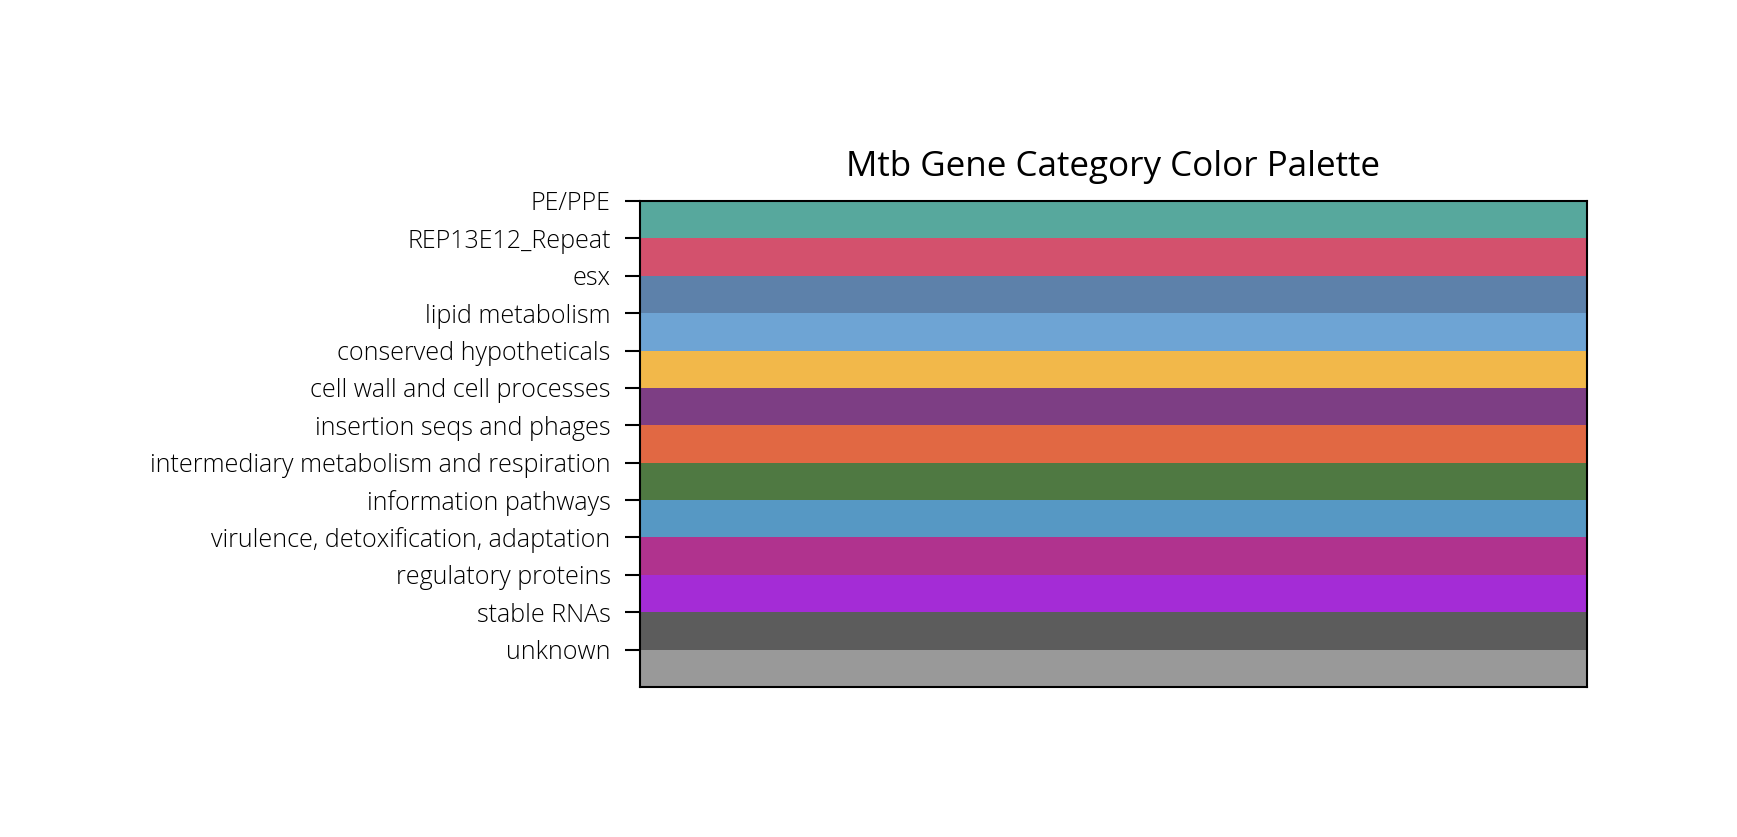

In [25]:
# Plot the colors
fig, ax = plt.subplots(figsize=(5, 2))
ax.set_xlim(0, 1)
ax.set_ylim(0, len(Mtb_GeneCat_ColorDict))
ax.set_xticks([])
ax.set_yticks(range(len(Mtb_GeneCat_ColorDict)))
ax.set_yticklabels(Mtb_GeneCat_ColorDict.keys(), fontsize=6)

for i, (category, color) in enumerate(Mtb_GeneCat_ColorDict.items()):
    ax.add_patch(plt.Rectangle((0, i), 1, 1, color=color))

plt.gca().invert_yaxis()
plt.title("Mtb Gene Category Color Palette")
plt.show()

# Pre-process Data for Genome Viz w/ `DNA-Features-Viewer`

### Import/setup DNA Features Viewer (For plotting H37rv genome annotations)

In [26]:
from dna_features_viewer import GraphicFeature, GraphicRecord, CircularGraphicRecord, BiopythonTranslator
from Bio import SeqIO
from Bio.SeqFeature import SeqFeature, FeatureLocation


In [27]:
BiopythonTranslator.label_fields = ['gene', 'label', 'source', 'locus_tag', 'note', 'gene', 'product']
BiopythonTranslator.ignored_features_types = ["source", "gene"]
BiopythonTranslator.default_feature_color = "lightgrey"

## Create H37Rv Genome Record + Results Features Objects

In [28]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"

In [29]:
records = list(SeqIO.parse(H37rv_Ref_GBK_PATH, "genbank"))
print(len(records))
Mtb_H37rv_SeqIO_Record = records[0]

CDS_Features = []

for feature in Mtb_H37rv_SeqIO_Record.features:
    if feature.type == "CDS":
        CDS_Features.append(feature) 
        # if "gene" in feature.qualifiers.keys():
        #     if feature.qualifiers["locus_tag"] == ['Rv1196']:
        #         print(feature)
        #         print()

# --- Manually add esxM (Rv1792) ---

# esxM gene info
esxM_start = 2030346  # GenBank is 0-based, so subtract 1 from 1-based start
esxM_end = 2030643    # end is exclusive in Biopython
esxM_seq = (
    "atggcctcacgttttatgacggatccgcatgcgatgcgggacatggcgggccgttttgaggtgcacgcccagacggtggaggacgaggctcgccggatgtgggcgtccgcgcaaaacatttccggtgcgggctggagtggcatggccgaggcgacctcgctagacaccatgacctagatgaatcaggcgtttcgcaacatcgtgaacatgctgcacggggtgcgtgacgggctggttcgcgacgccaacaactacgaacagcaagagcaggcctcccagcagatcctgagcagctag"
)

# Create the SeqFeature object
esxM_feature = SeqFeature(
    location=FeatureLocation(esxM_start, esxM_end, strand=1),
    type="CDS",
    qualifiers={
        "locus_tag": ["Rv1792"],
        "gene": ["esxM"],
        "product": ["esxM hypothetical protein"],
        "translation": [
            "MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMTMNQAFRNIVNMLHGVRDGLVRDANNYEQQEQASQQILSS"
        ]
    }
)

# Append to the list of CDS features
CDS_Features.append(esxM_feature)

Mtb_H37rv_SeqIO_Record.features = CDS_Features

Mtb_H37rv_Graphic_Record = BiopythonTranslator().translate_record(Mtb_H37rv_SeqIO_Record)
Mtb_H37rv_Graphic_Record.feature_level_height = 0

1


# Parse `Mtb151CI` Isolate Metadata

In [30]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [31]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [32]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  

SampleID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
SampleID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
SampleID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


In [33]:
WGA151CI_OrderOfSampleIDs_Phylo = ['N0153', 'N0072', 'mada_2-46', 'mada_1-44', 'mada_107', 'mada_1-1', 'mada_1-51',
                          'mada_1-39', 'mada_1-36', 'mada_117', 'mada_122', 'mada_118', 'mada_1-10', 'R27252',
                          'R23887', 'TB3091', '9050-05', '3003-06', '702-06', '696-05', '8651-04', 'TB3396',
                          '4549-04', 'TB1612', 'TB2780', 'TB3368', 'TB1236', 'TB2659', '8129-04', 'R30215',
                          'R25048', 'TB2512', 'TB2981', 'TB2995', 'TB3113', '706-05', 'R30078', 'R28012',
                          'R27657', 'R30234', 'R31095', 'R28703', 'R24120', 'R36431', 'R29816', 'S0070-08',
                          'N0155', 'N0145', 'R29598', 'R24100', 'S0107-01', 'R28581', 'S0256-08', 'S0085-01',
                          'S0089-01', 'mada_1-11', 'M0003941_3', 'mada_115', 'mada_2-42', 'R37765', '18_0621851',
                          'R22601', 'R27937', 'R18040', 'R18043', 'R27725', 'R26791', 'R20574', 'R20260', 'R21408',
                          'R23146', 'R28980', 'R32929', 'R26778', 'R30420', 'R21893', 'QC-9', 'QC-5', 'QC-3', 'N0004',
                          'mada_1-30', 'N0054', 'N1274', '01_R1134', 'TB2968', 'mada_1-53', 'mada_2-53', 'mada_1-50',
                          'mada_2-1', 'R23571', 'mada_123', 'mada_1-12', 'mada_1-15', 'mada_128', 'mada_1-38', 'TB3054',
                          'mada_126', 'mada_120', 'TB4620', 'M0016737_0', 'M0016395_7', 'R15311', 'TB2661', 'TB3386',
                          'TB3162', '02_R1179', 'M0010874_7', 'QC-7', 'QC-6', 'QC-1', '01_R1430', 'M0011368_9',
                          '02_R1896', 'mada_2-25', 'TB3237', 'mada_103', 'mada_112', 'mada_124', 'S0123-01', 'S0262-02',
                          'TB3251', 'M0017522_5', 'R30396', 'R20896', 'mada_1-32', 'S0106-01', 'R21839', 'R21363', 'R21770',
                          'MT_0080', 'mada_102', 'TB3334', 'M0014888_3', 'mada_151', 'TB3169', 'mada_105', 'QC-8', 'QC-10',
                          'QC-4', 'mada_129', 'mada_139', '02_R1708', '02_R0894', 'mada_2-31', 'mada_1-41', 'N1272', 'N1176',
                          'N1202', 'N0091', 'N1177', 'RW-TB008']


# Parse all individual variants per genome annotated by CDS effect (`WGA-151CI`)

In [34]:
Mtb151_AllVar_Dir = "../../Data/241030.Mtb151CI.AllVariants.Anno.V1/"

Mtb151_AllVar_TSVGZ              = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllVariants.V1.tsv.gz"
Mtb151_AllVar_WiCDSAnno_TSVGZ    = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllVariants.WiCDSAnno.V1.tsv.gz"
Mtb151_SNPs_WiInterSNPDist_TSVGZ = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllSNPs.WiInterSNPDists.V1.tsv"


In [35]:

Mtb151CI_AllAsm_AllVar_DF = pd.read_csv(Mtb151_AllVar_WiCDSAnno_TSVGZ, sep="\t")

# WGA151_AllVar_DF = Mtb151CI_AllAsm_AllVar_DF
AllAsm_AllVar_DF = Mtb151CI_AllAsm_AllVar_DF
AllAsm_AllVar_DF.shape

(260869, 20)

In [36]:
AllAsm_AllVar_DF["SampleID"].nunique()

151

# Parse HHRs tested for Enrichment of "Paralog-Matching" SNPs

In [37]:
HHR_TestForParalogSNPs_TSV = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/Analysis/4_Mtb_HHR_MutAttributes_V3/HHR.TestedForParalogSNPS.V1.tsv"

HHR_SNP_Sig_DF  = pd.read_csv(HHR_TestForParalogSNPs_TSV,
                              sep = "\t")

HHR_SNP_Sig_DF["Num_Overlap_Genes"] = HHR_SNP_Sig_DF["Overlap_Genes"].str.split(",").apply(len)

HHR_SNP_Sig_DF.shape

(61, 31)

In [38]:
HHR_SNP_Sig_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,NPossible_SNPs_Total,NPossible_ParalogSNPs,NObserved_SNPs_Total,NObserved_SNPs_MatchParalogSNP,p_value,log_p_value,neglog_p_value,NExpected_MatchParalogSNP,p_corr,neglog_p_corr,NucDivHotspot_Ovrlap,FoldEnrichment,LogFoldEnrichment,Log2FoldEnrichment,AbsEnrichment,SizeFactor,Num_Overlap_Genes
0,165,NC_000962.3,3710379,3712822,3711600.5,2443,"Rv3325,Rv3326,Rv3327",3,15,1,0,165,PR_HmRegion_165,1,7329,1,17,4,0.0,500.0,500.0,0.002320,1.000000e-40,500.0,0,1724.470588,3.236656,10.751938,3.997680,0.018605,3
1,25,NC_000962.3,606510,608060,607285.0,1550,"Rv0515,Rv0516c",0,1,1,0,25,PR_HmRegion_025,0,4650,1,10,3,0.0,500.0,500.0,0.002151,1.000000e-40,500.0,0,1395.000000,3.144574,10.446049,2.997849,0.013953,2
2,44,NC_000962.3,1169296,1170733,1170014.5,1437,Rv1047,1,5,3,0,44,PR_HmRegion_044,0,4311,2,34,16,0.0,500.0,500.0,0.015774,1.000000e-40,500.0,0,1014.352941,3.006189,9.986344,15.984226,0.074419,1
3,15,NC_000962.3,400151,401701,400926.0,1550,Rv0336,0,1,1,0,15,PR_HmRegion_015,0,4650,1,14,3,0.0,500.0,500.0,0.003011,1.000000e-40,500.0,0,996.428571,2.998446,9.960623,2.996989,0.013953,1
4,158,NC_000962.3,3481324,3482760,3482042.0,1436,Rv3115,1,5,3,0,158,PR_HmRegion_158,0,4308,2,64,29,0.0,500.0,500.0,0.029712,1.000000e-40,500.0,0,976.031250,2.989464,9.930784,28.970288,0.134884,1


# Import/parse processed H37rv genome annotations

In [39]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
#H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"
H37Rv_GenomeAnnotations_Genes_V2_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.V2.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_V2_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [40]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded,information pathways


### Define paths to H37Rv genome masking schemes

In [41]:
RepoRef_Dir = "../../References"

MaskingSchemes_Dir = f"{RepoRef_Dir}/Mtb_H37Rv_MaskingSchemes"
PLC_Scheme_BED = f"{MaskingSchemes_Dir}/201027_Mtb_H37rv_pLC_Regions_CoscollaExcludedGenes.bed"


### Define relevant H37Rv gene lists for analysis (PE/PPE, Esx, 13E12 gene)

In [42]:
ListOf_Esx_Symbols = list(Esx_Genes_DF["symbol"].values)
ListOf_Esx_RvIDs = list(Esx_Genes_DF["gene_id"].values)

In [43]:
listOf_PEPPE_Symbols = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["Symbol"].values )
listOf_PEPPE_RvIDs = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["H37rv_GeneID"].values )

In [44]:
listOf_13E12_Region_RvIDs = ["Rv0094c", "Rv0095c", "Rv0393", "Rv1572c", "Rv1572c", "Rv1128c", "Rv1148c", "Rv1587c", "Rv1588c", "Rv1702c", "Rv1945", "Rv2100", "Rv3466", "Rv3467"]  


# Parse H37Rv Reference sequences (Genome, Genes, Proteins)

## Parse H37Rv genome sequence (DNA)

In [45]:
from Bio import SeqIO


In [46]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"
H37Rv_FA = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.fasta"

H37Rv_Seq = SeqIO.read(H37Rv_FA, "fasta").seq
len(H37Rv_Seq)

4411532

## Parse H37Rv Protein (AA) and gene (DNA) sequences

In [47]:
O2_RefDir = "/n/data1/hms/dbmi/farhat/mm774/References"

MycoBrowser_RefFiles_Dir = f"{O2_RefDir}/190619_Mycobrowser_H37rv_ReferenceFiles"

H37Rv_Proteins_MycoBro_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta"
H37Rv_Proteins_MycoBro_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.esxM_Added.fasta"
H37Rv_Proteins_NCBI_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta"
H37RV_Genes_FA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_genes_v3.fasta"



H37Rv_FAA_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_proteins.faa"
H37Rv_FAA_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_proteins.esxM_Added.faa"
H37Rv_GBK_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_genomic.gbk"


In [48]:
!ls -1 $MycoBrowser_RefFiles_Dir

Mycobacterium_tuberculosis_H37Rv_genes_v3.fasta
Mycobacterium_tuberculosis_H37Rv_genome_v3.fasta
Mycobacterium_tuberculosis_H37Rv_genome_v3.fasta.fai
Mycobacterium_tuberculosis_H37Rv_gff_v3.gff
Mycobacterium_tuberculosis_H37Rv_gff_v3.REP13E12_Regions.gff
Mycobacterium_tuberculosis_H37Rv_proteins_v3.fasta
Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.esxM_Added.fasta
Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta
Mycobacterium_tuberculosis_H37Rv_txt_v3_PEPPE_subfamilies.txt
Mycobacterium_tuberculosis_H37Rv_txt_v3.txt.tsv


### Parse MycoBrowser Protein Seq Ref

In [49]:
dictOf_H37Rv_MycoBrow_ProtSeq = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37Rv_Proteins_MycoBro_FAA, "fasta"))):
    ShortID = record.name
    
    dictOf_H37Rv_MycoBrow_ProtSeq[ShortID] = record.seq


4091it [00:00, 175597.88it/s]


### Parse MycoBrowser Gene Seq Ref

In [50]:
dictOf_H37Rv_MycoBrow_Gene_Seq = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37RV_Genes_FA, "fasta"))):

    ShortID = record.name.split("|")[0]
    dictOf_H37Rv_MycoBrow_Gene_Seq[ShortID] = record.seq


4187it [00:00, 122734.24it/s]


In [51]:
list(dictOf_H37Rv_MycoBrow_Gene_Seq.keys())[:2]

['Rv3728', 'Rv3729']

### Parse NCBI Protein Seq Ref

In [52]:
dictOf_H37Rv_ProtSeq = {}
dictOf_H37Rv_ProtRecord = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37Rv_FAA_PATH, "fasta"))):
    Rec_Description = record.description
    dict_Attr = {}
    for i in Rec_Description.split(" "):
        ###Just looking for line with " " character (as key = value)
        if "=" in i:
            key = i.strip().split("=")[0].strip('"').strip('[')
            value = i.strip().split("=")[1].strip('"').strip(']')
            ###Put them in a dictionnary
            dict_Attr[key]=value
    
    ShortID = dict_Attr["locus_tag"]
    dictOf_H37Rv_ProtSeq[ShortID] = record.seq
    dictOf_H37Rv_ProtRecord[ShortID] = record


3907it [00:00, 22293.46it/s]


In [53]:
#dictOf_H37Rv_ProtSeq["Rv1196"]

In [54]:
#dictOf_H37Rv_ProtSeq["Rv1196"] == dictOf_H37Rv_MycoBrow_ProtSeq["Rv1196"]

In [55]:
dictOf_H37Rv_ProtSeq["Rv1792"]

Seq('MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMT')

In [56]:
dictOf_H37Rv_MycoBrow_ProtSeq["Rv1792"]

Seq('MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMT')

# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [57]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"



### Variants from the homology map alignments (For each pairwise alignment between PRs)
RvHmMap_Var_PerAln_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.tsv"
RvHmMap_Var_PerAln_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.snps.tsv"



### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [58]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                           sep="\t")

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 15)

In [59]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                               sep="\t")
HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 13)

In [60]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 15)

#### Peak at head of each HmMap Regions DFs

In [61]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004,0,PR_Set_5


In [62]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [63]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 25)

In [64]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 38)

In [65]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 35)

### Parse in HomologyMap Alignment Variants DFs

In [66]:
### paralog variants - Improved per alignment `cs` tag approach 
Mtb_HM_Var_PR_DF = pd.read_csv(RvHmMap_Var_PerAln_TSV, sep="\t")
print(Mtb_HM_Var_PR_DF.shape)

Mtb_HM_Var_PR_SNPs_DF = pd.read_csv(RvHmMap_Var_PerAln_SNPs_TSV, sep="\t")
print(Mtb_HM_Var_PR_SNPs_DF.shape)

(60402, 20)
(50203, 20)


In [67]:
Mtb_HM_Var_PR_SNPs_DF.head(4)

,Target_Name,Target_Start,Target_End,Strand,Ref,Alt,SNP,Type,Query_Name,Query_Start,Query_End,HmMap_Aln_ID,Aln_Query_Start,Aln_Query_End,Aln_Target_Start,Aln_Target_End,Aln_Strand,QueryOverlap_Genes,TargetOverlap_Genes,QueryParalog_RegionID
0,NC_000962.3,3082657,3082658,+,T,C,True,SNP,NC_000962.3,80412,80413,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
1,NC_000962.3,3082660,3082661,+,C,A,True,SNP,NC_000962.3,80415,80416,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
2,NC_000962.3,3082667,3082668,+,G,A,True,SNP,NC_000962.3,80422,80423,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
3,NC_000962.3,3082669,3082670,+,T,C,True,SNP,NC_000962.3,80424,80425,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523


In [68]:
TarCol = ['Target_Name', 'Target_Start', 'Target_End', 'Ref', 'Alt', 'SNP'] 

Mtb_HM_Var_PR_SNPs_Trim_DF = Mtb_HM_Var_PR_SNPs_DF[TarCol]

print(Mtb_HM_Var_PR_SNPs_Trim_DF.shape)

Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF = Mtb_HM_Var_PR_SNPs_Trim_DF.drop_duplicates()

print(Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF.shape)


(50203, 6)
(41454, 6)


In [69]:
Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF.head(3)

,Target_Name,Target_Start,Target_End,Ref,Alt,SNP
0,NC_000962.3,3082657,3082658,T,C,True
1,NC_000962.3,3082660,3082661,C,A,True
2,NC_000962.3,3082667,3082668,G,A,True


In [70]:
# Mtb_HM_Var_DF = pd.read_csv(RvHmMap_Var_TSV, sep="\t")
# Mtb_HM_Var_SNPs_DF = pd.read_csv(RvHmMap_Var_SNPs_TSV, sep="\t")

# print(Mtb_HM_Var_DF.shape)
# print(Mtb_HM_Var_SNPs_DF.shape)

In [71]:
Mtb_HM_Var_PR_SNPs_DF.head(5)

,Target_Name,Target_Start,Target_End,Strand,Ref,Alt,SNP,Type,Query_Name,Query_Start,Query_End,HmMap_Aln_ID,Aln_Query_Start,Aln_Query_End,Aln_Target_Start,Aln_Target_End,Aln_Strand,QueryOverlap_Genes,TargetOverlap_Genes,QueryParalog_RegionID
0,NC_000962.3,3082657,3082658,+,T,C,True,SNP,NC_000962.3,80412,80413,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
1,NC_000962.3,3082660,3082661,+,C,A,True,SNP,NC_000962.3,80415,80416,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
2,NC_000962.3,3082667,3082668,+,G,A,True,SNP,NC_000962.3,80422,80423,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
3,NC_000962.3,3082669,3082670,+,T,C,True,SNP,NC_000962.3,80424,80425,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
4,NC_000962.3,3082671,3082672,+,G,A,True,SNP,NC_000962.3,80426,80427,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523


In [72]:
HmMap_Aln_k19w19_NoOverlap_DF.head(5)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2
2,NC_000962.3,103705,105090,-,NC_000962.3,3883535,3884921,1346.0,1390.0,:6*cg:2-ac:3+gc:13*tc:2*tc:14*gc:23*tc:9*tc:3*...,0.968345,3884228.0,104397.5,631701.5,1385,1386,"Rv0094c,Rv0095c","Rv3466,Rv3467",False,False,0,0,NC_000962.3:103705-105090,NC_000962.3:3883535-3884921,NC_000962.3:103705-105090;NC_000962.3:3883535-...,2,103705,105130,177,3883535,3884921,PR_HmRegion_002,PR_HmRegion_180,2,180,0,0,PR_Set_3
3,NC_000962.3,103779,105130,+,NC_000962.3,1788513,1789865,1316.0,1354.0,:987*tc:5*tc:1*ga:6*ag:2*ga:5*tc:2*tc:5*at*gt:...,0.971935,1789189.0,104454.5,1684734.5,1351,1352,"Rv0094c,Rv0095c","Rv1587c,Rv1588c",False,False,0,0,NC_000962.3:103779-105130,NC_000962.3:1788513-1789865,NC_000962.3:103779-105130;NC_000962.3:1788513-...,2,103705,105130,73,1788513,1789865,PR_HmRegion_002,PR_HmRegion_074,2,74,0,0,PR_Set_3
4,NC_000962.3,149571,149808,-,NC_000962.3,1357376,1357613,195.0,241.0,:3*tc:5*ag:8*gt:2+t:2+ag:5-gcg:4*tc*ca:2*gc:1*...,0.809129,1357494.5,149689.5,1207805.0,237,237,PE_PGRS2,PE14,False,False,0,0,NC_000962.3:149571-149808,NC_000962.3:1357376-1357613,NC_000962.3:149571-149808;NC_000962.3:1357376-...,3,149571,149808,55,1357376,1357613,PR_HmRegion_003,PR_HmRegion_056,3,56,0,0,PR_Set_4


# Parse `Nuc-Div` results for `WGA-151CI` dataset

## Define NucDiv analysis file paths

In [73]:
AnalysisName = "250201.WGA151CI.V10"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

VCFT_NucDiv_Dir = f"{Target_Output_Dir}/VCFtools_SNV_NucDiv_AcrossH37Rv"

Pickle_PATH_WGA_NucDiv_PI_Dict = VCFT_NucDiv_Dir + f"/{AnalysisName}.SNVs.NucDiv.DictOfResults.pickle"   

#NucDiv_NoFilt_1kb_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.tsv"
NucDiv_NoFilt_1kb_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.Anno.tsv"
NucDiv_NoFilt_1kb_V2_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.Anno.V2.tsv"

NucDiv_NoFilt_Per1kb_V3_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.Anno.V3.tsv"



In [74]:
!head -n 2 $NucDiv_NoFilt_1kb_TSV_PATH

Chrom	Start	End	NucDiv	OverlapGenes	Middle	NucDiv_kb	NucDiv_Z	NucDiv_ModZ	IsNucDivHotspot
NC_000962.3	0	1000	0.000217905	dnaA	500.0	0.21790500000000002	-0.17877807777367116	0.12786281596276042	False


In [75]:
!head -n 2 $NucDiv_NoFilt_1kb_V2_TSV_PATH

Chrom	Start	End	NucDiv	OverlapGenes	Middle	NucDiv_kb	NucDiv_Z	NucDiv_ModZ	IsNucDivHotspot	N_HmMapAln_PR_Ovrlap	OvrlapWi_HmMapAln_PR	N_HmMapAln_LR_Ovrlap	OvrlapWi_HmMapAln_LR	N_LCR_Ovrlap	OvrlapWi_LowComplexityRegion	N_LowPmap_Ovrlap	OvrlapWi_LowPmap	PLC_Mask_Count	PLC_Mask_Ovrlap
NC_000962.3	0	1000	0.000217905	dnaA	500.0	0.217905	-0.1787780777736711	0.1278628159627603	False	0	0	0	0	0	0	0	0	0	0


In [76]:
!head -n 2 $NucDiv_NoFilt_Per1kb_V3_TSV_PATH

Chrom	Start	End	Middle	OverlapGenes	NucDiv_kb	NucDiv_ModZ	IsNucDivHotspot	OvrlapWi_HmMapAln_PR	OvrlapWi_HmMapAln_LR	OvrlapWi_LowComplexityRegion	OvrlapWi_LowPmap	PLC_Mask_Ovrlap
NC_000962.3	0	1000	500.0	dnaA	0.217905	0.1278628159627603	False	0	0	0	0	0


### Parse pickle of NucDiv stats

In [77]:
with open(Pickle_PATH_WGA_NucDiv_PI_Dict, "rb") as f: NucDiv_PI_Dict = pickle.load(f)
NucDiv_PI_Dict.keys()

dict_keys([('ALL', 1000)])

In [78]:
xx_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["XX"]
yy_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["YY"] * 1000


### Parse 1-kb NucDiv DF

In [79]:
# Read in TSV
WGA_NucDiv_PI_1kb_DF = pd.read_csv(NucDiv_NoFilt_1kb_V2_TSV_PATH, sep = "\t")
WGA_NucDiv_PI_1kb_DF.shape



(4421, 20)

In [80]:
WGA_NucDiv_PI_1kb_DF.head(4)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
0,NC_000962.3,0,1000,0.000218,dnaA,500.0,0.217905,-0.178778,0.127863,False,0,0,0,0,0,0,0,0,0,0
1,NC_000962.3,1000,2000,0.000791,dnaA,1500.0,0.790654,0.829172,2.920256,False,0,0,0,0,0,0,0,0,0,0
2,NC_000962.3,2000,3000,0.000306,dnaN,2500.0,0.305560,-0.024519,0.555218,False,0,0,0,0,0,0,0,0,0,0
3,NC_000962.3,3000,4000,0.000221,"dnaN,recF",3500.0,0.221073,-0.173203,0.143308,False,0,0,0,0,0,0,0,0,0,0


#### Peak at top 5 most diverse windows of the genome

In [81]:
WGA_NucDiv_PI_1kb_DF.sort_values("NucDiv_kb", ascending=False).head(5)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
104,NC_000962.3,104000,105000,0.015961,"Rv0094c,Rv0095c",104500.0,15.96060,27.525938,76.880144,True,2,1,0,0,0,0,3,1,2,1
1276,NC_000962.3,1276000,1277000,0.013222,Rv1148c,1276500.0,13.22200,22.706424,63.528313,True,2,1,0,0,0,0,3,1,1,1
1634,NC_000962.3,1634000,1635000,0.009038,PE_PGRS27,1634500.0,9.03773,15.342754,43.128231,True,2,1,0,0,2,1,2,1,1,1
2867,NC_000962.3,2867000,2868000,0.007695,"lppA,lppB,vapB18",2867500.0,7.69545,12.980548,36.584050,True,2,1,0,0,0,0,3,1,2,1
3842,NC_000962.3,3842000,3843000,0.007541,"Rv3424c,PPE57",3842500.0,7.54143,12.709497,35.833137,True,3,1,0,0,0,0,5,1,2,1


### Process NucDiv distribution stats

In [82]:
NucDiv_1kb_DF = WGA_NucDiv_PI_1kb_DF

# Calculate mean, median, standard deviation, and Median Absolute Deviation
median_1kb_PI = NucDiv_1kb_DF['NucDiv_kb'].median()
mean_1kb_PI = NucDiv_1kb_DF['NucDiv_kb'].mean()
std_1kb_PI = NucDiv_1kb_DF['NucDiv_kb'].std()
MAD_1kb_PI = np.median(np.abs(NucDiv_1kb_DF['NucDiv_kb'] - median_1kb_PI))

ModZ_10_NucDiv = (10 / 0.6745) * MAD_1kb_PI + median_1kb_PI


In [83]:
print("The modified Z score threshold is:,", ModZ_10_NucDiv)

The modified Z score threshold is:, 2.2427835218680507


### Define NucDiv Hospots (N = 37)

In [84]:
NucDiv_HSR_1kb_DF = NucDiv_1kb_DF.query("IsNucDivHotspot == True")
NucDiv_HSR_1kb_DF.shape

(37, 20)

In [85]:
NucDiv_HSR_1kb_DF.head(5)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
103,NC_000962.3,103000,104000,0.004051,"Rv0093c,Rv0094c",103500.0,4.05131,6.567424,18.817330,True,2,1,0,0,0,0,1,1,1,1
104,NC_000962.3,104000,105000,0.015961,"Rv0094c,Rv0095c",104500.0,15.96060,27.525938,76.880144,True,2,1,0,0,0,0,3,1,2,1
105,NC_000962.3,105000,106000,0.003371,"Rv0095c,PPE1",105500.0,3.37124,5.370605,15.501701,True,2,1,0,0,0,0,1,1,2,1
338,NC_000962.3,338000,339000,0.005144,PE_PGRS4,338500.0,5.14383,8.490090,24.143826,True,2,1,0,0,1,1,6,1,1,1
1095,NC_000962.3,1095000,1096000,0.003100,"rpmF,PE_PGRS18",1095500.0,3.10016,4.893546,14.180072,True,2,1,0,0,1,1,3,1,1,1


#### Extra Inspection of NucDiv DFs

In [86]:
NucDiv_1kb_DF.head(2)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
0,NC_000962.3,0,1000,0.000218,dnaA,500.0,0.217905,-0.178778,0.127863,False,0,0,0,0,0,0,0,0,0,0
1,NC_000962.3,1000,2000,0.000791,dnaA,1500.0,0.790654,0.829172,2.920256,False,0,0,0,0,0,0,0,0,0,0


In [87]:
NucDiv_1kb_DF["NucDiv_kb"].describe()

count    4421.000000
mean        0.319492
std         0.568232
min         0.000000
25%         0.078678
50%         0.191679
75%         0.405184
max        15.960600
Name: NucDiv_kb, dtype: float64

In [88]:
NucDiv_HSR_1kb_DF.head(4)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
103,NC_000962.3,103000,104000,0.004051,"Rv0093c,Rv0094c",103500.0,4.05131,6.567424,18.817330,True,2,1,0,0,0,0,1,1,1,1
104,NC_000962.3,104000,105000,0.015961,"Rv0094c,Rv0095c",104500.0,15.96060,27.525938,76.880144,True,2,1,0,0,0,0,3,1,2,1
105,NC_000962.3,105000,106000,0.003371,"Rv0095c,PPE1",105500.0,3.37124,5.370605,15.501701,True,2,1,0,0,0,0,1,1,2,1
338,NC_000962.3,338000,339000,0.005144,PE_PGRS4,338500.0,5.14383,8.490090,24.143826,True,2,1,0,0,1,1,6,1,1,1


In [89]:
NucDiv_HSR_1kb_DF.query("OvrlapWi_HmMapAln_PR == 1").shape

(36, 20)

In [90]:
NucDiv_HSR_1kb_DF.query("OvrlapWi_HmMapAln_PR == 0").shape

(1, 20)

## Create DF NucDiv Hotspot Peaks Labeled by Gene Category

In [91]:
NucDiv_HSR_1kb_WiCatLabels_V2_DF = NucDiv_HSR_1kb_DF.copy()

NDH_WinStart_To_FuncCat_Dict = {104000  : "REP13E12_Repeat",
                                338000  : "PE/PPE", 
                                1096000 : "PE/PPE", 
                                1276000 : "REP13E12_Repeat", 
                                1340000 : "PE/PPE", 
                                1341000 : "esx", 
                                1533000 : "PE/PPE", 
                                1634000 : "PE/PPE", 
                                1637000 : "PE/PPE", 
                                1789000 : "REP13E12_Repeat", 
                                2196000 : "REP13E12_Repeat", 
                                2262000 : "conserved hypotheticals", 
                                2338000 : "conserved hypotheticals", 
                                2626000 : "esx", 
                                2867000 : "cell wall and cell processes", 
                                2944000 : "PE/PPE", 
                                3135000 : "conserved hypotheticals", 
                                3732000 : "PE/PPE", 
                                3750000 : "PE/PPE", 
                                3842000 : "PE/PPE", 
                                3847000 : "PE/PPE", 
                                3883000 : "REP13E12_Repeat", 
                                3895000 : "PE/PPE",
                                3934000 : "PE/PPE",
                                3943000 : "PE/PPE",
                                3947000 : "PE/PPE",
                                4254000 : "insertion seqs and phages",
                                }

NucDiv_HSR_1kb_WiCatLabels_V2_DF["Func_Category_Peaks"] = NucDiv_HSR_1kb_WiCatLabels_V2_DF["Start"].map(NDH_WinStart_To_FuncCat_Dict).fillna("NotPeak")

NucDiv_HSR_PeaksOnly_DF = NucDiv_HSR_1kb_WiCatLabels_V2_DF.query("Func_Category_Peaks != 'NotPeak'")
NucDiv_HSR_PeaksOnly_DF.shape


(27, 21)

In [92]:
NucDiv_HSR_PeaksOnly_DF.head()

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap,Func_Category_Peaks
104,NC_000962.3,104000,105000,0.015961,"Rv0094c,Rv0095c",104500.0,15.96060,27.525938,76.880144,True,2,1,0,0,0,0,3,1,2,1,REP13E12_Repeat
338,NC_000962.3,338000,339000,0.005144,PE_PGRS4,338500.0,5.14383,8.490090,24.143826,True,2,1,0,0,1,1,6,1,1,1,PE/PPE
1096,NC_000962.3,1096000,1097000,0.004876,"PE_PGRS18,mprA",1096500.0,4.87615,8.019015,22.838773,True,2,1,0,0,1,1,1,1,1,1,PE/PPE
1276,NC_000962.3,1276000,1277000,0.013222,Rv1148c,1276500.0,13.22200,22.706424,63.528313,True,2,1,0,0,0,0,3,1,1,1,REP13E12_Repeat
1340,NC_000962.3,1340000,1341000,0.002840,"PPE18,esxK",1340500.0,2.84020,4.436057,12.912657,True,6,1,0,0,0,0,3,1,2,1,PE/PPE


In [93]:
NucDiv_HSR_PeaksOnly_DF["Func_Category_Peaks"].value_counts()

Func_Category_Peaks
PE/PPE                          15
REP13E12_Repeat                  5
conserved hypotheticals          3
esx                              2
cell wall and cell processes     1
insertion seqs and phages        1
Name: count, dtype: int64

# Parse `Mtb151-MainAnalysis` Gubbins Results

### Define dictionary of file paths for Gubbins analysis

In [94]:
AnalysisName = "250201.WGA151CI.V10"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

i_Gubbins_V1_OutputDir = f"{Target_Output_Dir}/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh"

Gubbins_V1_OutputDir = i_Gubbins_V1_OutputDir

i_Gubbins_OutPrefix = "Gubbins"

i_Gubbins_FullPrefix_PATH  = f"{i_Gubbins_V1_OutputDir}/{i_Gubbins_OutPrefix}"

i_Gubbins_FilePath_Dict = {}

i_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]           = f"{i_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
i_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]      = f"{i_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"
i_Gubbins_FilePath_Dict["BranchStats_CSV"]                 = f"{i_Gubbins_FullPrefix_PATH}.per_branch_statistics.csv"
i_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"]     = f"{i_Gubbins_FullPrefix_PATH}.per_branch_statistics.WithLineagePerNode.tsv"
i_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"]         = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPer1kb.tsv"
i_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"]        = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerGene.tsv"
#i_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedHomologousRegion.tsv"
i_Gubbins_FilePath_Dict["EventsPer_PR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedParalogRegion.tsv"
i_Gubbins_FilePath_Dict["EventsPer_LR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedLocalRepeatRegion.tsv"

i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]             = f"{i_Gubbins_FullPrefix_PATH}.recombination_predictions.Anno.tsv"
i_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"]              = f"{i_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.All.tsv"  
i_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"]       = f"{i_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv" 

i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"]        = f"{i_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.All.tsv"
i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"] = f"{i_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.EventSNPsOnly.tsv"


######### Add Event to Paralog Mapping Results File Paths ##########
EventMapping_ResultsDir = f"{Target_Output_Dir}/RecombEvent-To-HmRegion-Comparison-V3"

GRE_Anno_ByTopHomologMatch_TSV              = f"{EventMapping_ResultsDir}/GubbinsEvents.WiParalogMapping.V1.tsv"
EventMappingToAllParalogs_Info_TSV_PATH     = f"{EventMapping_ResultsDir}/EventMapping.EventsToAllHmRegions.SeqComparisonInfo.tsv"
Pickle_PATH_dictOf_EventAndHomolog_KmerComp = f"{EventMapping_ResultsDir}/EventMapping.DictOf.KmerComparisons.pickle"   


i_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"]       = GRE_Anno_ByTopHomologMatch_TSV
i_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"]       = EventMappingToAllParalogs_Info_TSV_PATH
i_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"]   = Pickle_PATH_dictOf_EventAndHomolog_KmerComp

HmRegions_MappedEvents_TSV = f"{EventMapping_ResultsDir}/GCE.Stats.PerMergedHmRegion.PRs.tsv"
HmPairs_MappedEvents_TSV   = f"{EventMapping_ResultsDir}/GCE.Stats.PerPairwiseAln.PRs.tsv"

i_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"] = HmRegions_MappedEvents_TSV
i_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"]       = HmPairs_MappedEvents_TSV

# Parsimony Scores (Fitch) for all mutations associated with each event
GCE_ParsimonyScores_PerEvent_TSV = f"{i_Gubbins_V1_OutputDir}/GCE.FitchParsimonyScores.PerEvent.tsv"
GCE_ParsimonyScores_PerSite_TSV = f"{i_Gubbins_V1_OutputDir}/GCE.FitchParsimonyScores.PerSite.tsv"

i_Gubbins_FilePath_Dict["ParsimonyQC_PerEvent_TSV"] = GCE_ParsimonyScores_PerEvent_TSV
i_Gubbins_FilePath_Dict["ParsimonyQC_PerSite_TSV"]  = GCE_ParsimonyScores_PerSite_TSV


####################################################################


## A) Parse table of ALL Gubbins Events (all putative recomb events) - `WGA-151-GCE` 

In [95]:
print( i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]) 

/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh/Gubbins.recombination_predictions.Anno.tsv


In [96]:
# Parse annotated events TSV
GRE_DF = pd.read_csv(i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"], sep = "\t")

# Convert the string column to a list of strings
GRE_DF['taxa_List'] = GRE_DF['taxa_List'].apply(ast.literal_eval)
GRE_DF["LenOfTaxaList"] = GRE_DF["taxa_List"].apply(len)

GRE_DF.shape

(324, 31)

## B) Parse Gubbins recombination events counted over regions (`1 kb window`, `Gene-level`, `HmRegion`)

In [97]:
GCE_CtPerGene_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"], sep = "\t")

GCE_CtPerGene_Atleast1_DF = GCE_CtPerGene_DF.query("pGCE_Count > 0")
GCE_CtPerGene_Atleast1_DF.shape

(76, 15)

In [98]:
GCE_PerPRStats_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventsPer_PR_H37Rv_TSV"] , sep = "\t")
GCE_PerPRStats_DF.shape

(200, 18)

In [99]:
GCE_PerLRStats_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventsPer_LR_H37Rv_TSV"] , sep = "\t")
GCE_PerLRStats_DF.shape

(50, 16)

In [100]:
257094 / 4411532

0.05827771395515209

In [101]:
256568 / 4411532

0.058158480999344446

## C) Parse Gubbins Events - branch-level stats

In [102]:
G_BranchStats_Filt_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"], sep = "\t")
G_BranchStats_Filt_DF.shape

(300, 15)

In [103]:
G_BranchStats_Filt_DF.head(1)

,Node,Total SNPs,Number of SNPs Inside Recombinations,Number of SNPs Outside Recombinations,Number of Recombination Blocks,Bases in Recombinations,Cumulative Bases in Recombinations,r/m,rho/theta,Genome Length,Bases in Clonal Frame,Lineage,BranchLen,Num_Tips_Downstream,Total_SNPs
0,N0072,328,36,292,4,391,3619,0.123288,0.013699,4411487,4408943,lineage1,295.04892,0.0,328


In [104]:
G_BranchStats_Filt_DF.query("Lineage == 'lineage4' ").sort_values("Num_Tips_Downstream", ascending=False).head(1)

,Node,Total SNPs,Number of SNPs Inside Recombinations,Number of SNPs Outside Recombinations,Number of Recombination Blocks,Bases in Recombinations,Cumulative Bases in Recombinations,r/m,rho/theta,Genome Length,Bases in Clonal Frame,Lineage,BranchLen,Num_Tips_Downstream,Total_SNPs
215,Node_65,208,16,192,2,946,1898,0.083333,0.010417,4411532,4409993,lineage4,199.414017,62.0,208


## D) Read in the "node_To_PrimaryLin_Dict" dictionary 

In [105]:
with open(i_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]) as json_file:
    node_To_PrimaryLin_Dict = json.load(json_file)

## E) Gubbins ASR SNP DFs

In [106]:
GubSNPs_All_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"], sep = "\t")
GubSNPs_All_DF.shape

(26508, 13)

In [107]:
GubSNPs_EventOnly_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"], sep = "\t")
GubSNPs_EventOnly_DF.shape

(2916, 13)

In [108]:
GubSNPs_CDSAnno_All_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"], sep = "\t")
GubSNPs_CDSAnno_All_V2_DF.shape

(26508, 23)

In [109]:
GubSNPs_CDSAnno_EventOnly_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"], sep = "\t")
GubSNPs_CDSAnno_EventOnly_V2_DF.shape

(2916, 23)

### Parse Gubbins ASR SNP files (w/ Codon Variant Annotations)

In [110]:
Gub_SNPs_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"],
                                         sep = "\t")
Gub_SNPs_V2_DF.shape

(26508, 23)

In [111]:
#Gub_SNPs_V2_DF.head(1)

In [112]:
Gub_SNPs_V2_DF["MissenseMut"].value_counts() 

MissenseMut
True     13883
False    12625
Name: count, dtype: int64

In [113]:
Gub_SNPs_V2_DF["MissenseMut"].value_counts()

MissenseMut
True     13883
False    12625
Name: count, dtype: int64

## F) Parse `Event-to-Paralog-Mapping` results

### F.1) Event table anno by paralog match

In [114]:
GRE_AnnoByMatch_DF = pd.read_csv(i_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"],
                                 sep = "\t")


# Convert the string column to a list of strings
GRE_AnnoByMatch_DF['taxa_List']     = GRE_AnnoByMatch_DF['taxa_List'].apply(ast.literal_eval)
GRE_AnnoByMatch_DF["LenOfTaxaList"] = GRE_AnnoByMatch_DF["taxa_List"].apply(len)


##### Label GC Events by overlap w/ NucDiv Hotspots ######
RE_CoordCols = ("seqname", "start_0based", "end_1based")
GenomeAnno_CoordCols = ("Chrom", "Start", "End")

print(GRE_AnnoByMatch_DF.shape)
GRE_AnnoByMatch_DF = bf.count_overlaps(GRE_AnnoByMatch_DF, NucDiv_HSR_1kb_DF, 
                               cols1 = RE_CoordCols,
                               cols2 = GenomeAnno_CoordCols).rename(columns={'count': 'N_NucDivHotSpots'})
print(GRE_AnnoByMatch_DF.shape)

##########################################################

GRE_ABM_DF = GRE_AnnoByMatch_DF
GRE_ABM_DF.shape

(324, 46)
(324, 47)


(324, 47)

### F.2) Event to all paralogs DF

In [115]:
GCE_MatchToEachPR_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"],
                               sep = "\t")

GCE_MatchToEachPR_DF.shape

(590, 15)

### F.3) Event to paralog details dict

In [116]:
with open(i_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"], "rb") as f:
    
    dictOf_FullKmerAnalysis_PerEvent = pickle.load(f)
    
print(len(list(dictOf_FullKmerAnalysis_PerEvent.keys()) ))

295


### F.4) HmMap and GCE Stats annotated onto HmRegions and HmMap alignment pairs  
- Parse in mapping results quantified across `Paralogous Regions and each `HmMap-Alignment`

In [117]:
HmPair_EventCt_DF = pd.read_csv(i_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"],
                                sep = "\t")

HmPair_EventCt_DF["Aln_N_SNPs"] = HmPair_EventCt_DF["cs"].apply(count_substitutions_in_cs)


HmPair_EventCt_NoPerf_DF = HmPair_EventCt_DF.query("SeqID < 100")
HmPair_EventsOnly_DF = HmPair_EventCt_NoPerf_DF.query("EventsMapped > 0")


HmRegions_DonorAndEventCt_DF = pd.read_csv(i_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"],
                                           sep = "\t")


In [118]:
HmRegions_DonorAndEventCt_DF.head(1)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,0.0,0,0,0.0,0.0,0.0,0.0,20,20


In [119]:
HmPair_EventCt_DF.head(2)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1,0.0,"(1400000, 1450000]",1425000.0,Rv0071,Rv2774c,0.0,0,20,58.823529,1,1409268.5,1409.2685,64.262295
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2,0.0,"(1600000, 1650000]",1625000.0,"Rv0072,Rv0073","Rv2563,glnQ",0.0,0,374,181.729835,1,1609866.0,1609.8660,65.328110


## G) Parsimony Scoring of SNPs per GC Event


In [120]:
GCE_FitchQC_PerEvent_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ParsimonyQC_PerEvent_TSV"],
                                      sep = "\t")

GCE_FitchQC_PerSite_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ParsimonyQC_PerSite_TSV"],
                                      sep = "\t")

print("Parsimony Scores - per GC Event - DF shape:", GCE_FitchQC_PerEvent_DF.shape)
print("Parsimony Scores - per SNP of each GC Event - DF shape:", GCE_FitchQC_PerSite_DF.shape)


Parsimony Scores - per GC Event - DF shape: (324, 11)
Parsimony Scores - per SNP of each GC Event - DF shape: (2916, 10)


# Process Gubbins Tree (`Mtb-151CI`)

## Parse and annotate phylogeny

In [121]:
## 1) Parse Gubbins Tree w/ ETE3

i_Gubbins_T = Tree(i_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"],
                   format = 1)

# Root the Mtb-151CI tree on the L8 isolate
i_T_RootPoint = i_Gubbins_T.get_leaves_by_name("RW-TB008")[0]    
i_Gubbins_T.set_outgroup(i_T_RootPoint)

## 2) Parsing over each node of the tree (ETE3), get ML BRANCH LENGTH and Number of descendents per node
Tree_BranchLen_Dict, Tree_NumDescendants_PerNode_Dict = get_BranchLengths_and_DescendantCounts_FromTree(i_Gubbins_T)

## 3) Label each LEAF within phylogeny by MTBC Lineage + Infer lineage of each internal node of the tree
i_Gubbins_T = annotate_tree_with_lineages(i_Gubbins_T,
                                          SampleID_To_PrimLineage_Dict)

# i_Gubbins_T, Tree_PrimaryLin_PerNode_Dict = infer_InternalNode_Lineages(i_Gubbins_T,
#                                                                         SampleID_To_PrimLineage_Dict)

                          

Number of leaves processed: 151


In [122]:
MTBC_AncestralNode = i_Gubbins_T.search_nodes(name="Node_150")[0]

print(MTBC_AncestralNode.name)

Node_150


# Viz `Mtb-151CI` phylogeny with branches colored by MTBC Lineage

In [123]:
Mtb_151CI_Tree_V1 = style_ETE3_Tree_ByMtbLineage_V1(i_Gubbins_T,
                                                   Mtb_LinToColor_Dict,
                                                   node_To_PrimaryLin_Dict, #Tree_PrimaryLin_PerNode_Dict,
                                                   verbose=False)


### Viz `Mtb151CI` Tree -  w/ ETE3

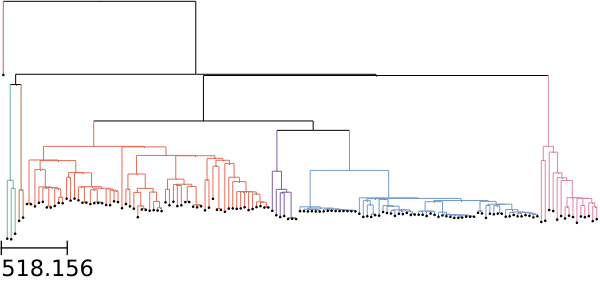

In [124]:
in_Tree = Mtb_151CI_Tree_V1.copy()
in_Tree.render("%%inline", w = 600, tree_style = ts_ColLin)

# Classify & Divide sets of GC Events based on Paralog Mapping results

In [125]:
GCE_All_DF = GRE_AnnoByMatch_DF
GCE_ABM_DF = GRE_AnnoByMatch_DF

# Seperate GC Event Info DF into GCEs WITH and WITHOUT paralogs
GCE_InPR_DF = GCE_All_DF.query("NumHmTargets > 0")
GCE_NotInPR_DF = GCE_All_DF.query("NumHmTargets == 0")

mGCE_DF = GRE_AnnoByMatch_DF.query("MappedEvent == True") #.query("Max_KmerMatch_ToHm > 0.5")
GCE_Mapped_DF = mGCE_DF

GCE_NotMapped_DF = GRE_AnnoByMatch_DF.query("MappedEvent == False") #.query("Max_KmerMatch_ToHm <= 0.5")
GCE_NotMapped_InPR_DF = GCE_NotMapped_DF.query("NumHmTargets > 0")

GCE_NotMapped_NotInPR_DF = GCE_NotMapped_DF.query("NumHmTargets == 0")
GRE_ABM_NoPR_InLR_DF = GRE_ABM_DF.query("N_HmMapAln_PR_Ovrlap == 0 & (N_HmMapAln_LR_Ovrlap > 0 | N_LCR_Ovrlap > 0 | N_LowPmap_Ovrlap > 0) ")  
GRE_ABM_NoPR_NoLR_NoLowPmap_DF  = GRE_ABM_DF.query("N_HmMapAln_PR_Ovrlap == 0 & N_HmMapAln_LR_Ovrlap == 0 & N_LCR_Ovrlap == 0 & N_LowPmap_Ovrlap == 0 ")


print("# of TOTAL detected events", GCE_All_DF.shape[0])

print("# of detected events IN a Paralog-Region:", GCE_InPR_DF.shape[0])
print("# of detected events NOT IN a Paralog-Region:", GCE_NotInPR_DF.shape[0])
print("")
print("# of mapped events", GCE_Mapped_DF.shape[0])
print("# of NOT MAPPED events:", GCE_NotMapped_DF.shape[0])

print("# of NOT MAPPED events IN a Paralog-Region:", GCE_NotMapped_InPR_DF.shape[0])
#print("# of NOT MAPPED events NOT IN a Paralog-Region:", GCE_NotMapped_NotInPR_DF.shape[0])


# of TOTAL detected events 324
# of detected events IN a Paralog-Region: 295
# of detected events NOT IN a Paralog-Region: 29

# of mapped events 217
# of NOT MAPPED events: 107
# of NOT MAPPED events IN a Paralog-Region: 78


In [160]:
GCE_ABM_DF.query("EventID == 'Event_295'")

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,N_NucDivHotSpots
294,NC_000962.3,3895067,3895257,.,Node_31,Node_30,412.863731,25,"[TB3162, TB2661, TB3386]",3895066,3895161.5,191,lineage4,3,PPE60,Rv3478,Event_295,False,True,False,False,PR_HmRegion_182,2,1,0,0,0,0,3,1,3,False,0.12,2,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.9565,1856048.5,115,1,"PE13,PPE18-H37Rv-1338923-1340433","PE13,PPE18",0.88,1856048.5,True,1


# Part 1: Analysis of overlap between GC events & NucDiv hotspots

Key questions are:
- What % of GC events overlap with an initially identified NucDiv hotspot?
- What % of NucDiv hotspots contained a GC event?

### Create a 1-kb window summary of NucDiv, mGC + pGC event counts, and HHR overlap

In [126]:
RE_CoordCols = ("seqname", "start_0based", "end_1based")
GenomeAnno_CoordCols = ("Chrom", "Start", "End")
Hm_Query_CoordCols = ("Query_Name", "Query_Start", "Query_End")
Hm_Target_CoordCols = ("Target_Name", "Target_Start", "Target_End")
NucDiv_CoordCols = ("Chrom", "Start", "End")

NucDiv_WiGCECt_DF = bf.count_overlaps(WGA_NucDiv_PI_1kb_DF,
                                      GCE_Mapped_DF,
                                      cols1 = ("Chrom", "Start", "End"),
                                      cols2 = RE_CoordCols).rename(columns={'count': 'N_mGCE'})

NucDiv_WiGCECt_DF = bf.count_overlaps(NucDiv_WiGCECt_DF,
                                      GRE_ABM_DF,
                                      cols1 = ("Chrom", "Start", "End"),
                                      cols2 = RE_CoordCols).rename(columns={'count': 'N_pGCE'})

NucDiv_WiGCECt_DF = bf.count_overlaps(NucDiv_WiGCECt_DF,
                                          HmMap_Aln_k19w19_NoOverlap_DF, 
                                          cols1 = NucDiv_CoordCols,
                                          cols2 = Hm_Target_CoordCols ).rename(columns={'count': 'N_Ovrlap_ParalogAlns'})

#### Add counts of (TOTAL Paralog-SNPs per HmRegion)

NucDiv_WiGCECt_DF = bf.count_overlaps(NucDiv_WiGCECt_DF,
                                              Mtb_HM_Var_PR_SNPs_DF,
                                              cols1 = ("Chrom", "Start", "End"),
                                              cols2 = Hm_Target_CoordCols).rename(columns={'count': 'Num_PR_SNPs_All'})

#### Add counts of UNIQUE PR-SNPs per HmRegion
NucDiv_WiGCECt_DF = bf.count_overlaps(NucDiv_WiGCECt_DF,
                                      Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF,
                                      cols1 = ("Chrom", "Start", "End"),
                                      cols2 = Hm_Target_CoordCols).rename(columns={'count': 'Num_PR_SNPs_Unq'})

NucDiv_WiGCECt_DF.shape


(4421, 25)

### Save NucDiv + GCE Counts per 1 kb window

In [127]:
!mkdir ./PerKbWin_NucDiv_GCE_Stats/

mkdir: cannot create directory ‘./PerKbWin_NucDiv_GCE_Stats/’: File exists


In [128]:
NucDiv_WiGCECt_DF.to_csv("./PerKbWin_NucDiv_GCE_Stats/Rv.PerKbStats.DivAndGCE.tsv", sep ="\t", index=False)

### Q 2.1: What % of GCEs overlap with an initially identified NucDiv hotspot? (208/324, 64%)

In [129]:
GCE_All_DF.query("N_NucDivHotSpots > 0").shape[0]

208

In [130]:
GCE_All_DF.shape[0]

324

In [131]:
GCE_All_DF.query("N_NucDivHotSpots > 0").shape[0] / GCE_All_DF.shape[0]

0.6419753086419753

### Q 2.2: What % of NucDiv hotspots overlap with at least 1 DETECTED GC event? (33/37, 89%)

In [132]:
NucDiv_WiGCECt_DF.query("IsNucDivHotspot == True & N_pGCE > 0").shape

(33, 25)

In [133]:
NucDiv_WiGCECt_DF.query("IsNucDivHotspot == True & N_pGCE > 0").shape[0] / NucDiv_WiGCECt_DF.query("IsNucDivHotspot == True").shape[0]   

0.8918918918918919

### Q 2.3: What % of NucDiv hotspots overlap with at least 1 MAPPED GC event? (28/37, 76%)

In [134]:
NucDiv_WiGCECt_DF.query("IsNucDivHotspot == True & N_mGCE > 0").shape   

(28, 25)

In [135]:
NucDiv_WiGCECt_DF.query("IsNucDivHotspot == True & N_mGCE > 0").shape[0] / NucDiv_WiGCECt_DF.query("IsNucDivHotspot == True").shape[0]   

0.7567567567567568

In [136]:
#NucDiv_WiGCECt_DF.query("IsNucDivHotspot == True & N_mGCE == 0")

# Part 2: Pre-process + Viz Nuc Diversity Stats Genome-wide

In [137]:
NucDiv_HSR_PeaksOnly_DF.shape

(27, 21)

In [138]:
NucDiv_HSR_PeaksOnly_DF.head(3)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap,Func_Category_Peaks
104,NC_000962.3,104000,105000,0.015961,"Rv0094c,Rv0095c",104500.0,15.96060,27.525938,76.880144,True,2,1,0,0,0,0,3,1,2,1,REP13E12_Repeat
338,NC_000962.3,338000,339000,0.005144,PE_PGRS4,338500.0,5.14383,8.490090,24.143826,True,2,1,0,0,1,1,6,1,1,1,PE/PPE
1096,NC_000962.3,1096000,1097000,0.004876,"PE_PGRS18,mprA",1096500.0,4.87615,8.019015,22.838773,True,2,1,0,0,1,1,1,1,1,1,PE/PPE


In [139]:
ModZ_10_NucDiv

2.2427835218680507

In [140]:
NucDiv_WiGCECt_DF["N_pGCE"].describe()

count      4421.0
mean     0.088668
std      0.859765
min           0.0
25%           0.0
50%           0.0
75%           0.0
max          28.0
Name: N_pGCE, dtype: Float64

## Plot Genome-wide NucDiv + peaks labeled by gene category

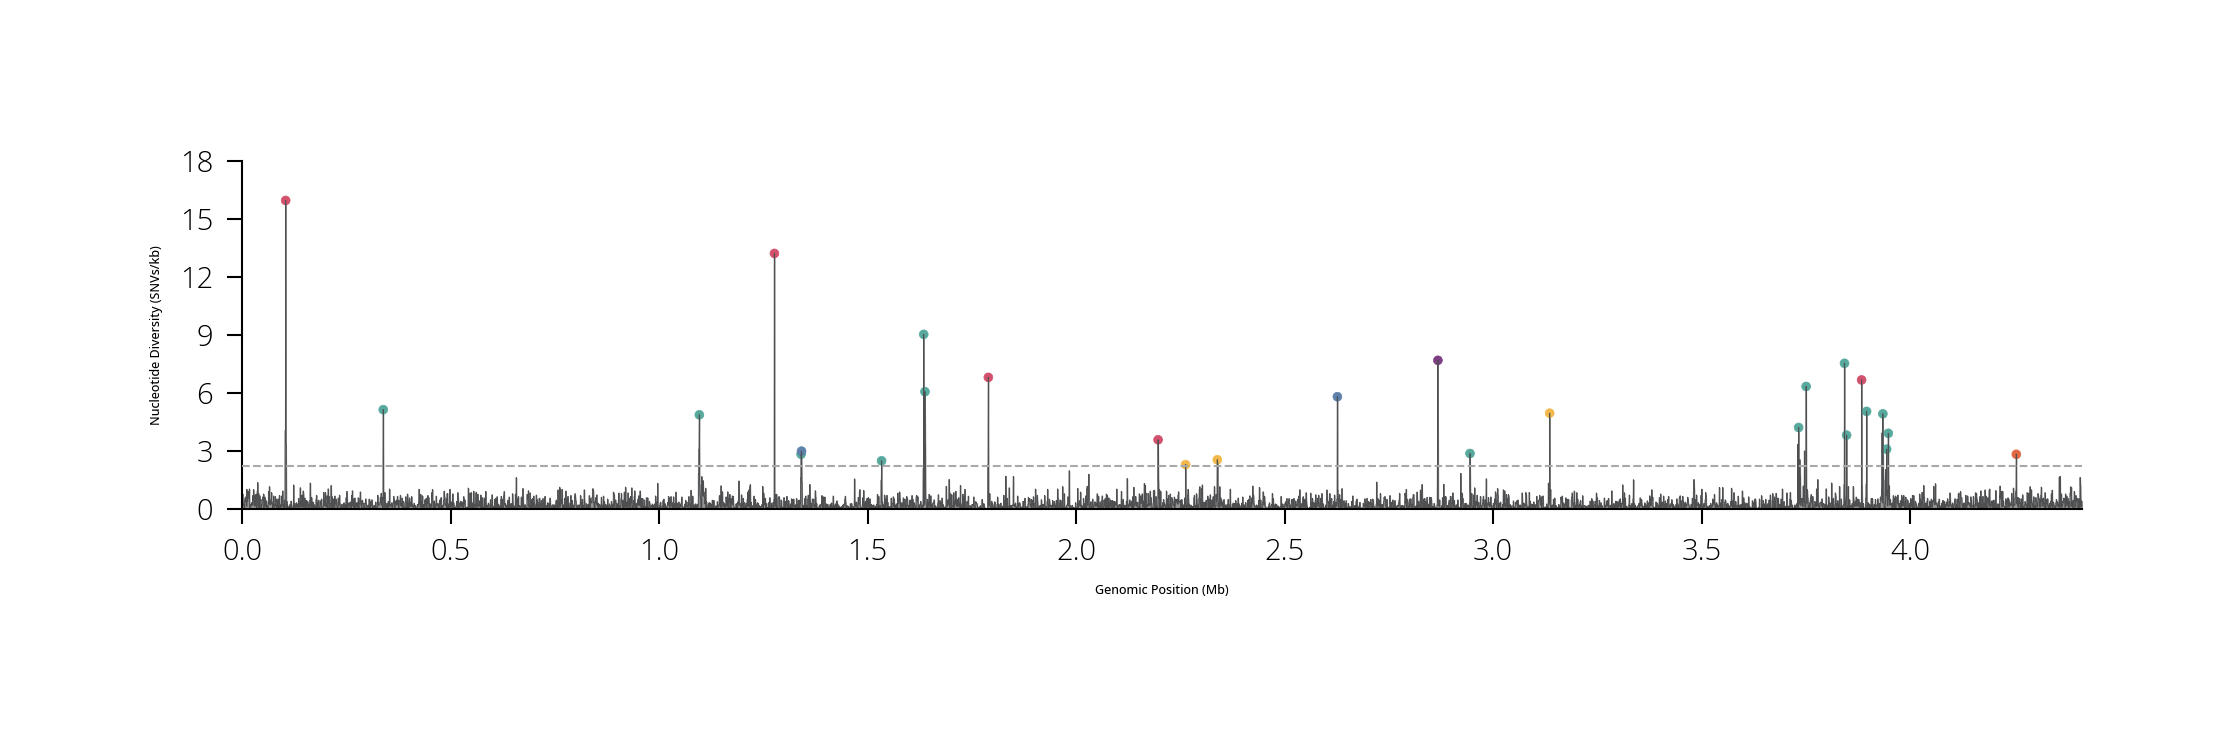

In [141]:
Div_df = NucDiv_WiGCECt_DF

# build step arrays
Div_x_step = np.r_[Div_df["Start"].to_numpy(), Div_df["End"].iloc[-1]]
Div_y_step = np.r_[Div_df["NucDiv_kb"].to_numpy(), Div_df["NucDiv_kb"].iloc[-1]]

#xx_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["XX"]
#yy_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["YY"] * 1000

fig, axs = plt.subplots(1, 1, figsize=(6.65, 1.7), sharex=True)

axs.step(Div_x_step, Div_y_step, where="post",
         color = '#4E4F51',
         linewidth=0.2)

axs.fill_between(Div_x_step, Div_y_step,
                 color = '#4E4F51', lw=0.3, alpha = 0.6)

axs.hlines(y = ModZ_10_NucDiv, xmin=0, xmax=5000000, color = "darkgrey",
           linewidth=0.5,  linestyles="--", zorder=3)

sns.scatterplot(x="Middle", y="NucDiv_kb",
    hue = "Func_Category_Peaks",  # Set hue to category column
    palette = Mtb_GeneCat_ColorDict,  # Use our predefined color mapping
    data = NucDiv_HSR_PeaksOnly_DF,
    ax=axs,
    size=7, edgecolor="face",  # Optional: makes dots stand out
    alpha=1, legend=False, zorder=1)

axs.set_xlabel('Genomic Position (Mb)', fontsize = 3)
axs.set_ylabel('Nucleotide Diversity (SNVs/kb)', fontsize = 3)
axs.set_ylim(0, 18)
plt.xlim(0, 4412000)

axs.xaxis.set_major_formatter(FuncFormatter(bp_to_mb))

tick_positions_y = [0, 3, 6, 9, 12, 15, 18]
axs.set_yticks(tick_positions_y)
axs.set_yticklabels([str(tick) for tick in tick_positions_y])

sns.despine()
plt.tight_layout()
plt.show()


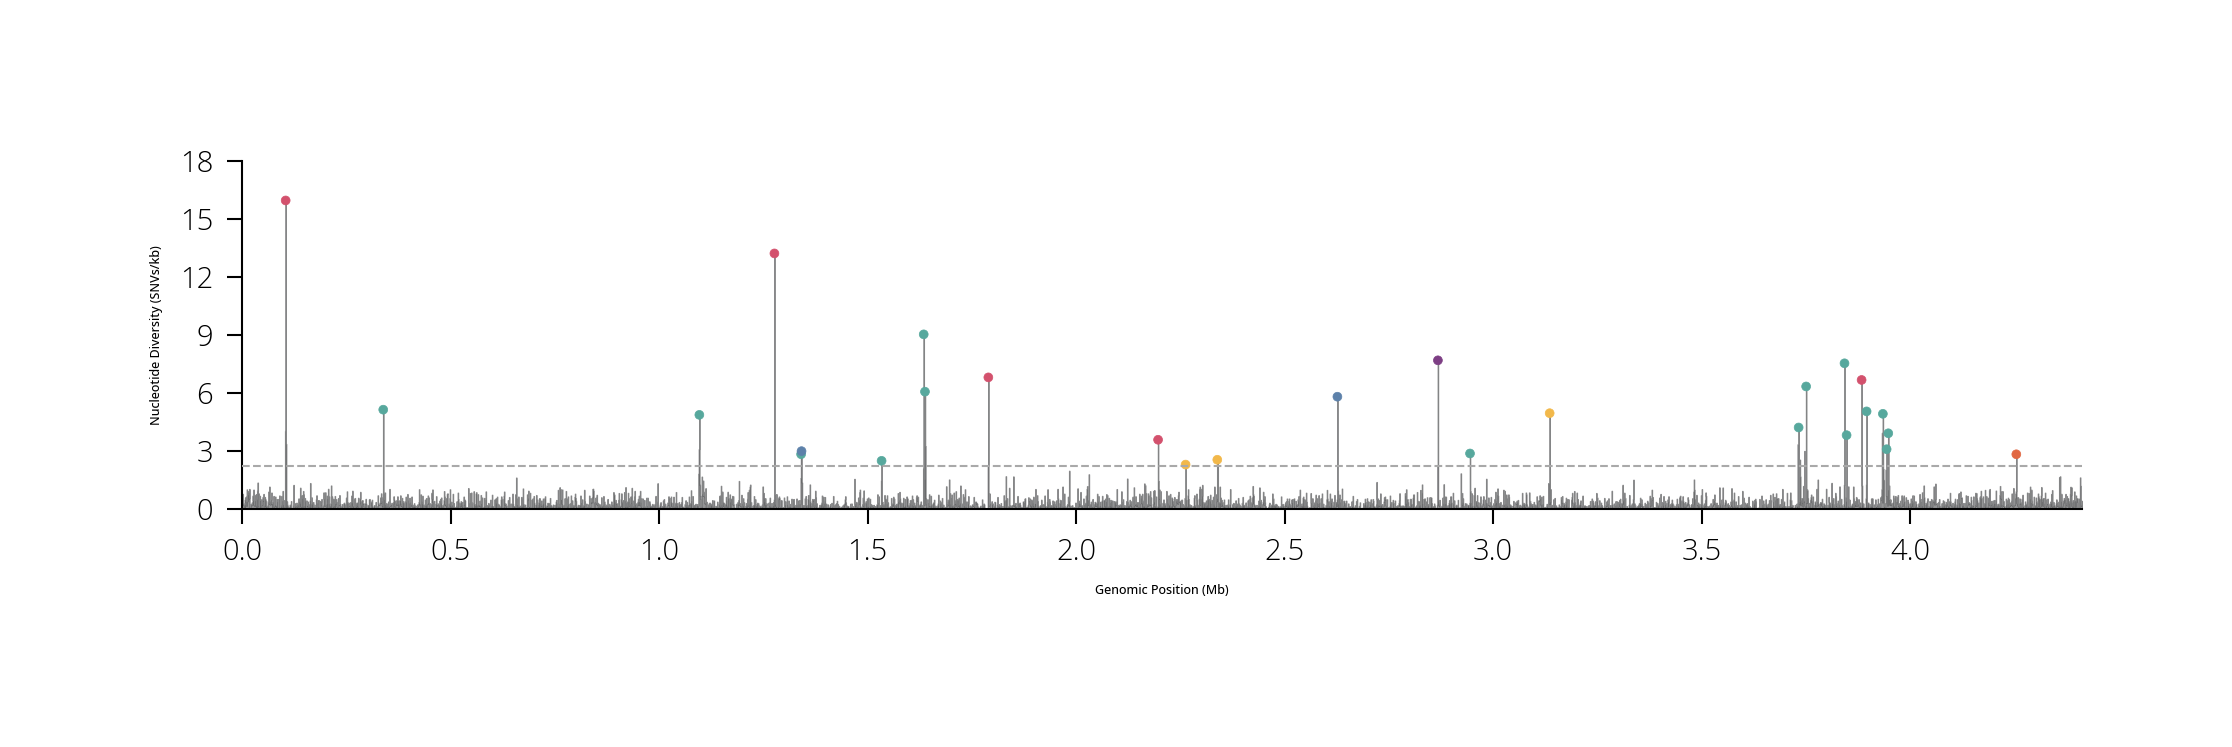

In [142]:
fig, axs = plt.subplots(1, 1, figsize=(6.65, 1.7), sharex=True)

xx_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["XX"]
yy_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["YY"] * 1000

axs.fill_between(xx_1kb_All_np, yy_1kb_All_np,
                 color = '#4E4F51', lw=0.3, alpha = 0.6)

axs.hlines(y = ModZ_10_NucDiv, xmin=0, xmax=5000000, color = "darkgrey",
           linewidth=0.5,  linestyles="--", zorder=3)

sns.scatterplot(x="Middle", y="NucDiv_kb",
    hue = "Func_Category_Peaks",  # Set hue to category column
    palette = Mtb_GeneCat_ColorDict,  # Use our predefined color mapping
    data = NucDiv_HSR_PeaksOnly_DF,
    ax=axs,
    size=7, edgecolor="face",  # Optional: makes dots stand out
    alpha=1, legend=False, zorder=1)

axs.set_xlabel('Genomic Position (Mb)', fontsize = 3)
axs.set_ylabel('Nucleotide Diversity (SNVs/kb)', fontsize = 3)
axs.set_ylim(0, 18)
plt.xlim(0, 4412000)

axs.xaxis.set_major_formatter(FuncFormatter(bp_to_mb))

tick_positions_y = [0, 3, 6, 9, 12, 15, 18]
axs.set_yticks(tick_positions_y)
axs.set_yticklabels([str(tick) for tick in tick_positions_y])

sns.despine()
plt.tight_layout()
plt.show()


## Genome-wide NucDiv viz - circular view

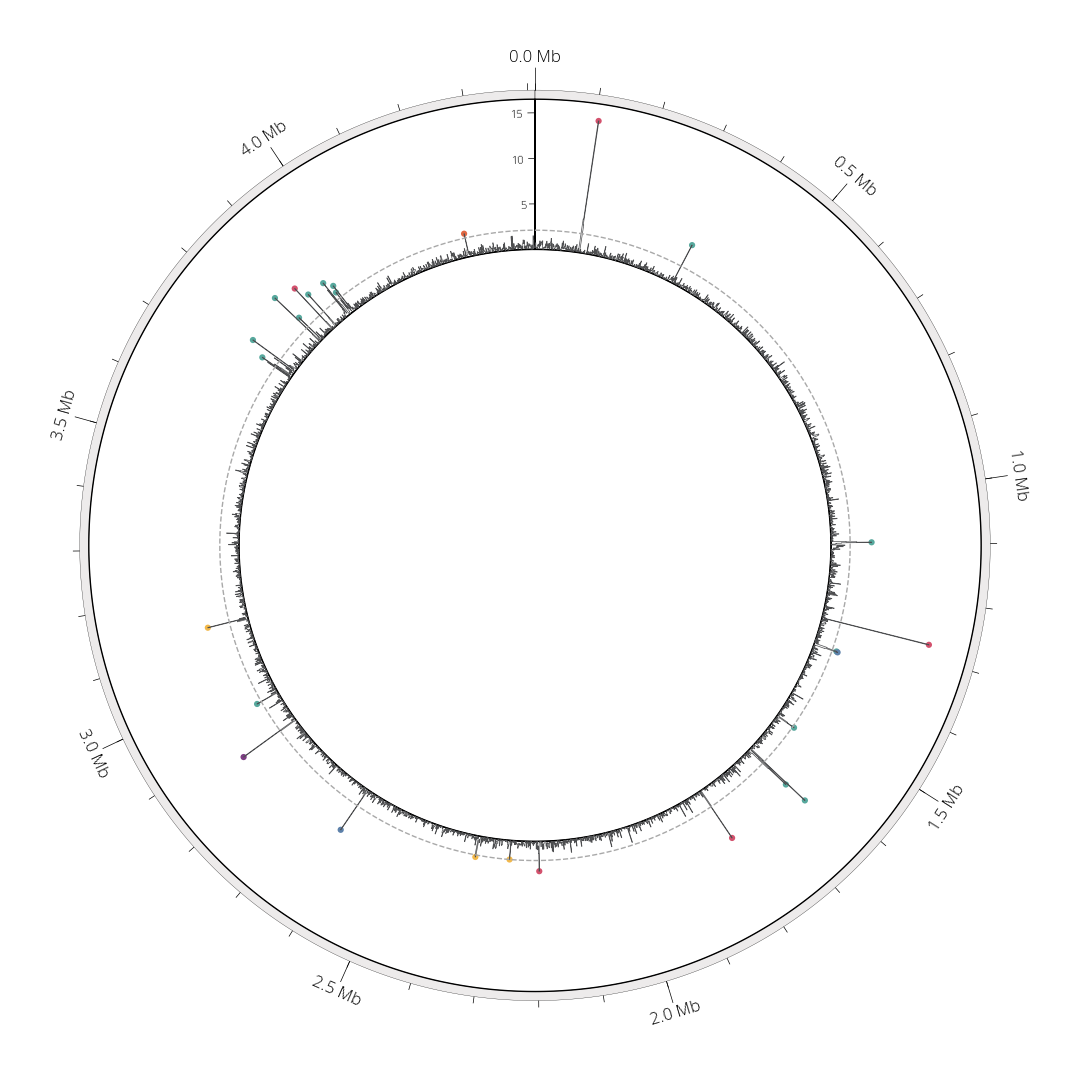

In [143]:
# main fig params
color_dict = {'nucdiv': '#4E4F51',
              'events': '#39618C',
              'arcs': '#F6605E',
              'hm_arcs': "gray",
              'scale_track': '#edebeb'}

circos = Circos(sectors={"NC_000962.3": 4411532}, endspace=False)
#circos.text("M. tuberculosis Genome \n(H37Rv, NC_000962)", size=12, r=20)
sector = circos.get_sector("NC_000962.3")

## SCALE TRACK
major_ticks_interval, minor_ticks_interval = 500000, 100000
scale_track = sector.add_track((98, 100))

# background color and line
scale_track.axis(fc=color_dict['scale_track'], 
                 lw=0.2)

# ticks
scale_track.xticks_by_interval(major_ticks_interval, 
                               label_size=12, tick_length=5, 
                               outer=True,
                               show_bottom_line=False,
                               label_orientation='horizontal',
                               line_kws=dict(ec='black'),
                               label_formatter=lambda v: f"{v/ 10 ** 6:.1f} Mb")

scale_track.xticks_by_interval(minor_ticks_interval, tick_length=1.5, show_label=False)

#####################
xaxis_track1 = sector.add_track((65, 65.1))
xaxis_track1.axis()

track1 = sector.add_track((65, 98), ) #r_pad_ratio=0.1)
track1.axis(lw=1)

track1.line(xx_1kb_All_np[:-19], yy_1kb_All_np[:-19],
            alpha=1, 
            lw= 0.5,
            vmax = 18,
            color = color_dict['nucdiv'],
            label = "Nucleotide Diversity (SNVs\kb)",)

track1.line([0, 4411532], [ModZ_10_NucDiv , ModZ_10_NucDiv],
            vmax = 17.5,
            lw=1, ls="dashed", color = "darkgrey")

NDHS_Pos = NucDiv_HSR_PeaksOnly_DF["Middle"].values
NDHS_NucDiv = NucDiv_HSR_PeaksOnly_DF["NucDiv_kb"].values
NDHS_Colors = NucDiv_HSR_PeaksOnly_DF['Func_Category_Peaks'].map(Mtb_GeneCat_ColorDict)

track1.scatter(np.array(NDHS_Pos), np.array( NDHS_NucDiv),
                     vmax = 18, color = NDHS_Colors,
                     s = 20, marker='o',)

y = [5, 10, 15]
y_labels = ["5", "10", "15",] 
track1.yticks(y, y_labels, vmax = 16.5, 
              side = "left", label_size = 8)

fig = circos.plotfig(figsize = (10, 10))

# Add legend
handles = [
    Patch(color = color_dict['nucdiv'], label="Nucleotide Diversity (SNVs\kb)"),
]

#_ = circos.ax.legend(handles=handles, bbox_to_anchor=(1.5, 1), loc="right", fontsize=10)

#fig.savefig('NucDiv.1kbwindows.Circos.WiHomologyLinks.V1.pdf')


# Part 3: Viz Genomic distribution of GCE Events

## 0) Organize key data tables

### Get 1-kb windows w/ GCEs detected BUT W/ NO OVERLAP W/ PARALOG REGION

In [144]:
GCE_NotInPR_DF.shape

(29, 47)

In [145]:
Rv_1kb_NucDiv_GCE_DF = NucDiv_WiGCECt_DF

RvWin_CoordCols = ("Chrom", "Start", "End")

Rv_1kb_NucDiv_GCE_DF = bf.count_overlaps(Rv_1kb_NucDiv_GCE_DF,
                                         GCE_NotInPR_DF,
                                         cols1 = RvWin_CoordCols,
                                         cols2 = RE_CoordCols).rename(columns={'count': 'N_GCE_NoParalogRegionOvrlap'})

Rv_1kb_NucDiv_GCE_DF.shape

(4421, 26)

In [146]:
Rv_1kb_NucDiv_GCE_NoPR_DF = Rv_1kb_NucDiv_GCE_DF.query("N_GCE_NoParalogRegionOvrlap > 0")
Rv_1kb_NucDiv_GCE_NoPR_DF.shape

(18, 26)

### Get table of all PRs w/ any detected GCE

In [147]:
PR_GCE_Info_WiDetectedGCE_DF = HmRegions_DonorAndEventCt_DF.query("N_Events_Putative > 0")
PR_GCE_Info_WiDetectedGCE_DF.shape

(54, 24)

In [148]:
PR_GCE_Info_WiDetectedGCE_DF.head(4)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3,10.5,19,31,8.5,29.5,0.288136,0.612903,68,35
9,9,NC_000962.3,332698,336379,334538.5,3681,"vapC25,vapB25,PE_PGRS3",0,4,4,4,9,PR_HmRegion_009,0,PR_Set_10,8.0,4,4,-4.0,12.0,-0.333333,1.000000,960,838
10,10,NC_000962.3,336565,339142,337853.5,2577,PE_PGRS4,0,2,2,2,10,PR_HmRegion_010,0,PR_Set_10,2.0,6,10,4.0,8.0,0.500000,0.600000,732,629
18,18,NC_000962.3,473743,474099,473921.0,356,Rv0393,0,1,1,1,18,PR_HmRegion_018,0,PR_Set_15,2.0,2,2,0.0,4.0,0.000000,1.000000,18,18


In [149]:
HmRegions_DonorAndEventCt_DF["N_Events_Putative"].sum()

296

In [150]:
PR_GCE_Info_WiDetectedGCE_DF["N_Events_Putative"].sum()

296

In [151]:
GCE_PerPRStats_DF["pGCE_Count"].sum()

296

In [152]:
GCE_PerLRStats_DF["pGCE_Count"].sum()

46

## 1) Viz GCE freq across Mtb genome - Linear - Per PR + NonPR kb windows

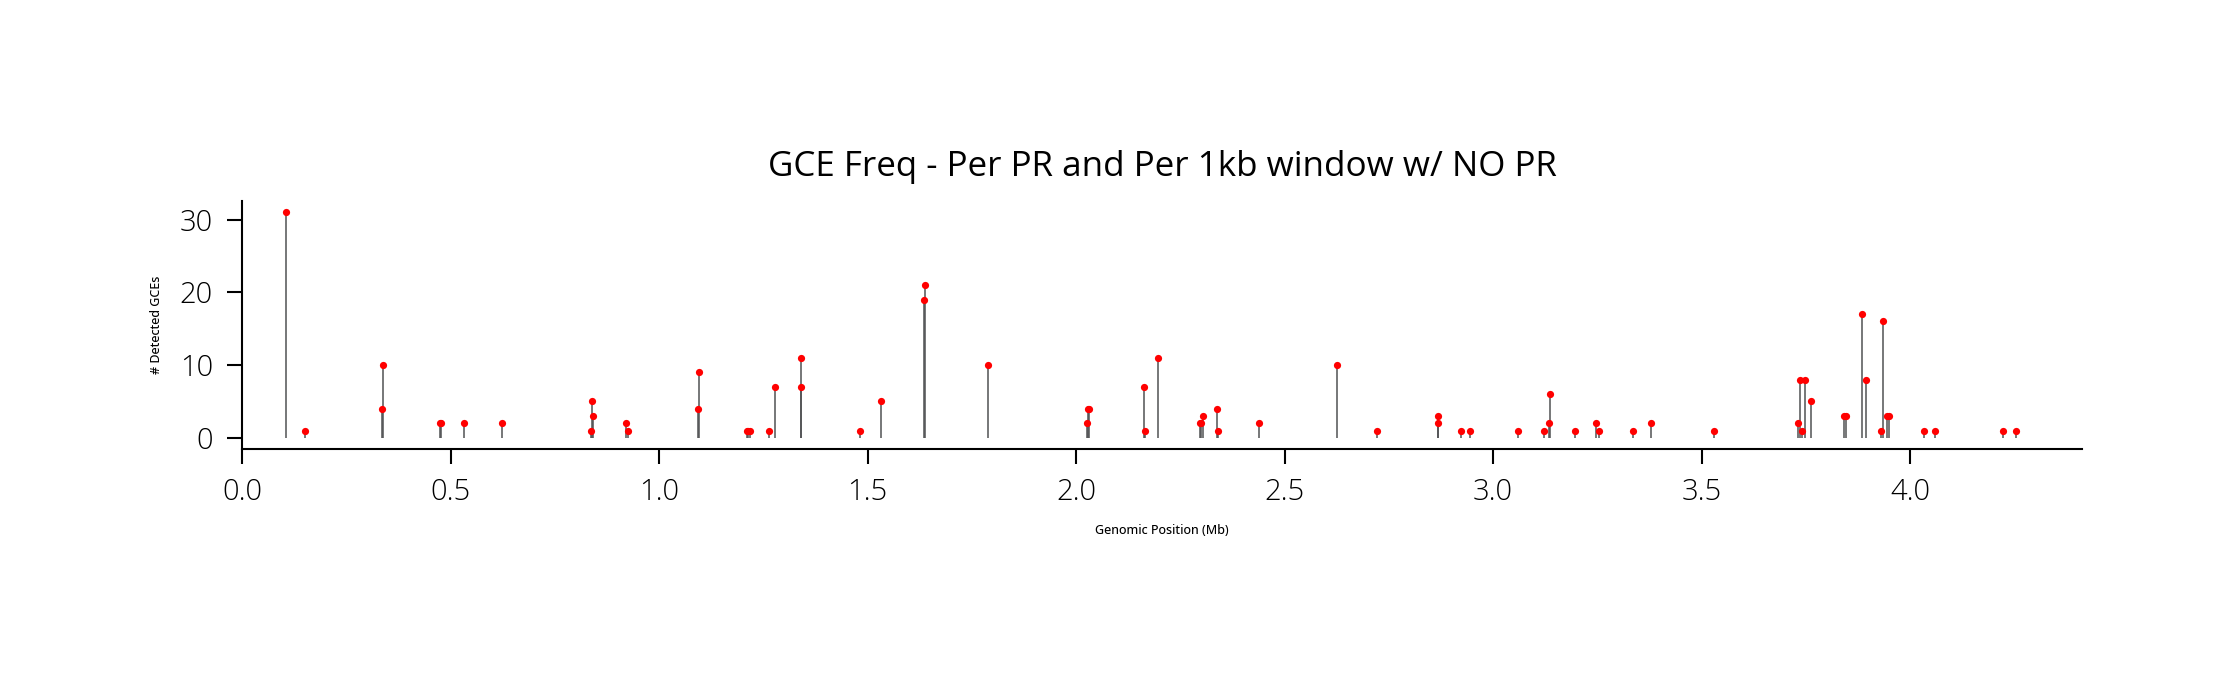

In [153]:
# Get positions + numbers for GCE Paralog Region lollipops
x_PR_mid = PR_GCE_Info_WiDetectedGCE_DF["Center"].to_numpy()
y_PR_pGCE = PR_GCE_Info_WiDetectedGCE_DF["N_Events_Putative"].to_numpy()


# Get positions + numbers for GCE NON-PR windows lollipops
x_NonPRWin_mid = Rv_1kb_NucDiv_GCE_NoPR_DF["Middle"].to_numpy()
y_NonPRWin_pGCE = Rv_1kb_NucDiv_GCE_NoPR_DF["N_pGCE"].to_numpy()


line_color = "#4E4F51"

fig, ax1 = plt.subplots(1, 1, figsize=(6.65, 1.5) )

##### Plot GCEs detected per PR ######
ax1.vlines(x_PR_mid, ymin=0, ymax = y_PR_pGCE,
           color = line_color, linewidth=0.4, alpha=0.9)

ax1.scatter(x_PR_mid, y_PR_pGCE,
            color= 'red', s=3, zorder=3)
######################################


##### Plot GCEs detected per NonPR Window ######
ax1.vlines(x_NonPRWin_mid, ymin = 0, ymax = y_NonPRWin_pGCE,
           color = line_color,
           linewidth = 0.4, alpha=0.9)

ax1.scatter(x_NonPRWin_mid, y_NonPRWin_pGCE,
            color= 'red', s = 3, zorder=3)

#############################################

#ax1.set_ylim(0, 30)
ax1.set_ylabel("# Detected GCEs", fontsize=3)
ax1.set_xlabel("Genomic Position (Mb)", fontsize=3)

# Shared x-axis formatting
ax1.set_xlim(0, 4412000)
ax1.xaxis.set_major_formatter(FuncFormatter(bp_to_mb))

ax1.set_title("GCE Freq - Per PR and Per 1kb window w/ NO PR")

sns.despine(ax=ax1)
plt.tight_layout()
plt.show()


## 2) Viz GCE freq across Mtb genome - Circular

In [154]:
!mkdir ./Fig3.GCE_Results/

mkdir: cannot create directory ‘./Fig3.GCE_Results/’: File exists


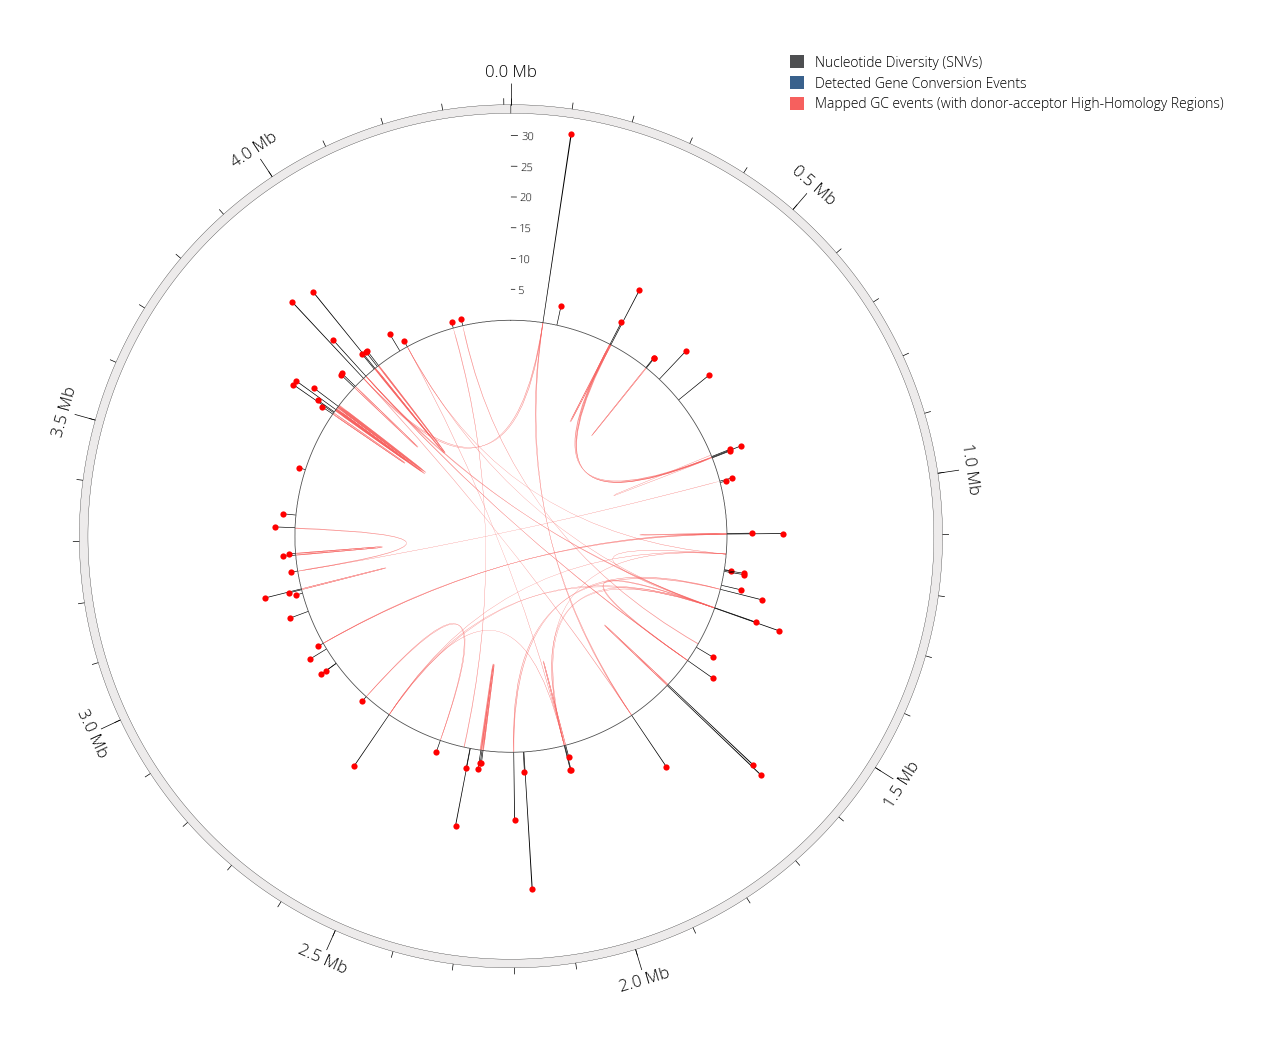

In [155]:
# main fig params
color_dict = {'nucdiv': '#4E4F51',
              'events': '#39618C',
              'GC_arcs': '#F6605E',
              'hm_arcs' : 'blue', #'grey',
              'scale_track': '#edebeb'}

circos = Circos(sectors={"NC_000962.3": 4411532}, endspace=False)
sector = circos.get_sector("NC_000962.3")

### Preprocess GCE Counts Info for plotting ###

# Get positions + numbers for GCE Paralog Region lollipops
x_PR_mid = PR_GCE_Info_WiDetectedGCE_DF["Center"].to_numpy()
y_PR_pGCE = PR_GCE_Info_WiDetectedGCE_DF["N_Events_Putative"].to_numpy()


# Get positions + numbers for GCE NON-PR windows lollipops
x_NonPRWin_mid = Rv_1kb_NucDiv_GCE_NoPR_DF["Middle"].to_numpy()
y_NonPRWin_pGCE = Rv_1kb_NucDiv_GCE_NoPR_DF["N_pGCE"].to_numpy()


## SCALE TRACK
major_ticks_interval, minor_ticks_interval = 500000, 100000
scale_track = sector.add_track((98, 100))

# background color and line
scale_track.axis(fc=color_dict['scale_track'], 
                 lw=0.2)

# ticks
scale_track.xticks_by_interval(major_ticks_interval, 
                               label_size=12, tick_length=5, 
                               outer=True, show_bottom_line=False,
                               label_orientation='horizontal', line_kws=dict(ec='black'),
                               label_formatter=lambda v: f"{v/ 10 ** 6:.1f} Mb")

scale_track.xticks_by_interval(minor_ticks_interval, tick_length=1.5, show_label=False)


## EVENTS TRACK
events_axis_track = sector.add_track((50, 50.1))
events_axis_track.axis(lw=0.2)

events_track = sector.add_track((50.1, 100), 
                                r_pad_ratio=0)
events_track.axis(lw=0)


# Plotting the "lollipop" sticks
#events_count_track.vlines(genome_positions, ymin=0, ymax=n_events_putative, color='black')

# Adding the points with circular markers and customized size and color


############ Plot GCEs detected per PR ############

events_track.bar(np.array(x_PR_mid),
                     np.array( y_PR_pGCE),
                     vmax = np.max(np.array( y_PR_pGCE)) + 4,
                     color= "black", width = 2000)

events_track.scatter(np.array(x_PR_mid),
                     np.array( y_PR_pGCE),
                     vmax = np.max(np.array( y_PR_pGCE)) + 4,
                     
                     color= "red",
                     s = 20,
                     marker='o',)

##################################################


############ Plot GCEs detected per NonPR Window ############


events_track.bar(np.array(x_NonPRWin_mid),
                     np.array( y_NonPRWin_pGCE),
                     vmax = np.max(np.array( y_NonPRWin_pGCE)) + 4,
                     color= "black", width = 2000)

events_track.scatter(np.array(x_NonPRWin_mid),
                     np.array( y_NonPRWin_pGCE),
                     vmax = np.max(np.array( y_NonPRWin_pGCE)) + 4,
                     
                     color= "red",
                     s = 20,
                     marker='o',)

##############################################################

y = [5, 10, 15, 20, 25, 30 ] 
y_labels = list(map(str, y))
events_track.yticks(y, y_labels,
                    vmax = np.max(np.array( y_PR_pGCE)) + 4)

## HOMOLOGY
# for i, row in HmPair_DF.iterrows():
#     i_region1 = (row["Query_Name"], row["Query_Start"] - 250, row["Query_End"] + 250)
#     i_region2 = (row["Target_Name"], row["Target_Start"] - 250, row["Target_End"] + 250)
#     circos.link(i_region1,
#                 i_region2,
#                 color = color_dict['hm_arcs'], direction = 1, alpha = 0.1)


## MAPPED EVENTS
for i, row in HmPair_EventsOnly_DF.iterrows():
    eventRegion = (row["Query_Name"], row["Query_Start"] - 250, row["Query_End"] + 250)

    Possible_DonorRegion = (row["Target_Name"], row["Target_Start"] - 250, row["Target_End"] + 250)

    circos.link(eventRegion,
                Possible_DonorRegion,
                color=color_dict['GC_arcs'],
                direction = 1, alpha = 0.7)

##########################################
fig = circos.plotfig(figsize = (12, 12))

# Add legend
handles = [
    Patch(color=color_dict['nucdiv'], label="Nucleotide Diversity (SNVs)"),
    Patch(color=color_dict['events'], label="Detected Gene Conversion Events"),
    Patch(color=color_dict['GC_arcs'], label="Mapped GC events (with donor-acceptor High-Homology Regions)"),
    #Patch(color= "blue", label="High-Homology Regions w/ no mapped events"),

]

_ = circos.ax.legend(handles=handles, bbox_to_anchor=(1.3, 1), loc="right", fontsize=10)

# Save the figure to a PDF file
fig.savefig('./Fig3.GCE_Results/Fig3.Circos.DetectedGCE_WiMappedGCELinks.V2.svg')


## 3) Viz GCE freq + NucDiv + Mapped Events - Circular - V1

In [156]:
!mkdir ./Fig3.GCE_Results/

mkdir: cannot create directory ‘./Fig3.GCE_Results/’: File exists


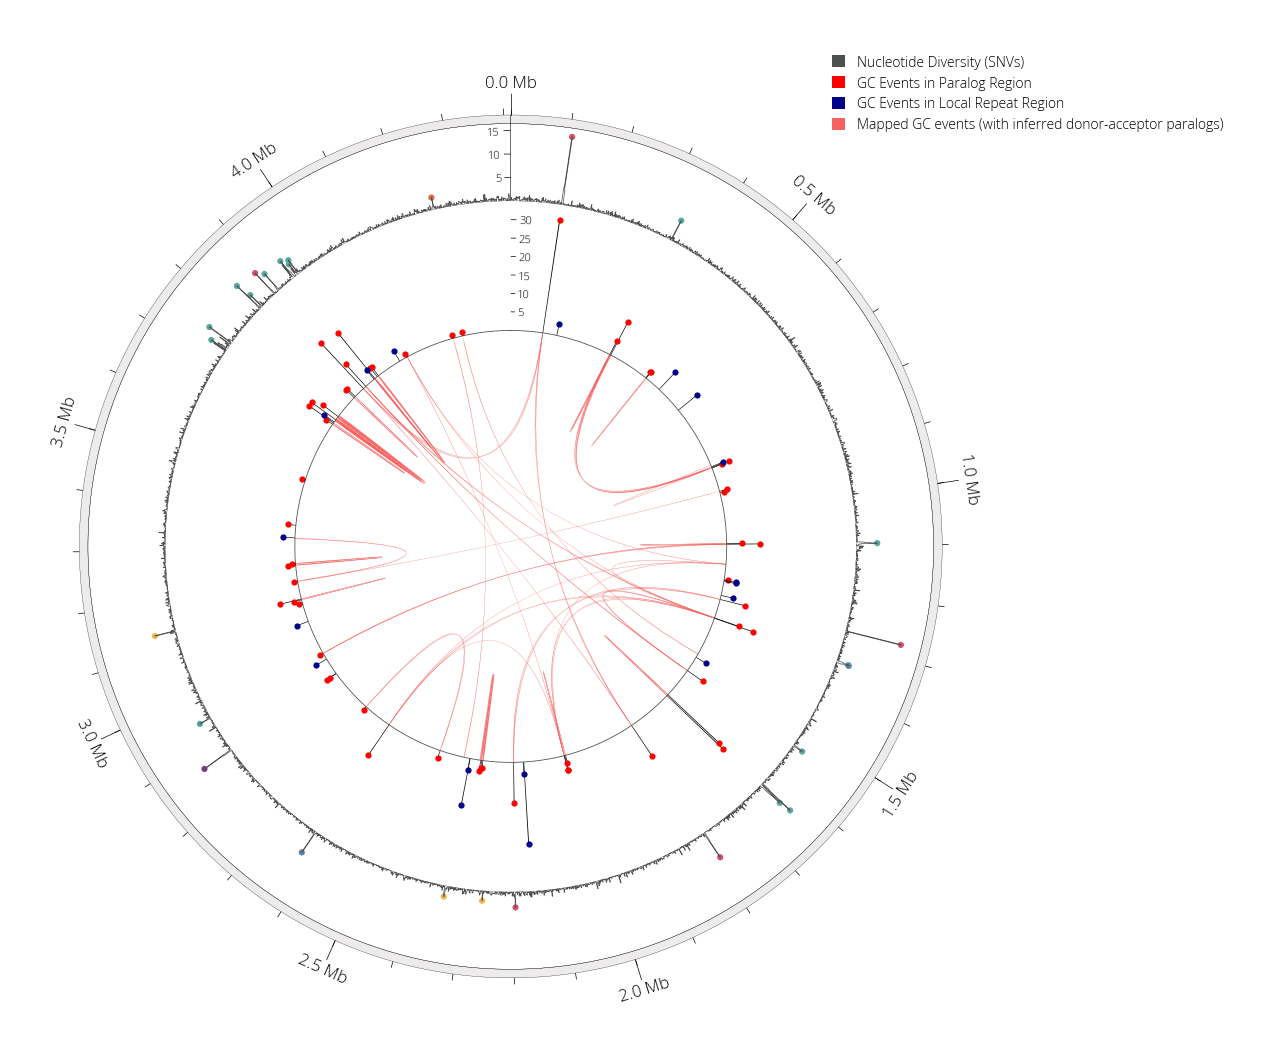

In [157]:
# main fig params
color_dict = {'nucdiv': '#4E4F51',
              'events': '#39618C',
              'GCE_InPR': 'red',
              'GCE_InLocalRepeat': '#00008B',
              'GC_arcs': '#F6605E',
              'hm_arcs' : 'blue', #'grey',
              'scale_track': '#edebeb'}

circos = Circos(sectors={"NC_000962.3": 4411532}, endspace=False)
sector = circos.get_sector("NC_000962.3")




## SCALE TRACK
major_ticks_interval, minor_ticks_interval = 500000, 100000
scale_track = sector.add_track((98, 100))

# background color and line
scale_track.axis(fc=color_dict['scale_track'], 
                 lw=0.2)

# ticks
scale_track.xticks_by_interval(major_ticks_interval, 
                               label_size=12, tick_length=5, 
                               outer=True, show_bottom_line=False,
                               label_orientation='horizontal', line_kws=dict(ec='black'),
                               label_formatter=lambda v: f"{v/ 10 ** 6:.1f} Mb")

scale_track.xticks_by_interval(minor_ticks_interval, tick_length=1.5, show_label=False)



## NUCDIV TRACK

nucdiv_track = sector.add_track((80.1, 98), 
                                r_pad_ratio=0)
nucdiv_track.axis(lw=0.2)

nucdiv_track.line(xx_1kb_All_np[:-19],
                  yy_1kb_All_np[:-19],
                  alpha=1,
                  vmax = 18,
                  lw = 0.5,
                  color = color_dict['nucdiv'],
                  label = "Nucleotide Diveristy (SNPs/kb)")

NDHS_Pos = NucDiv_HSR_PeaksOnly_DF["Middle"].values
NDHS_NucDiv = NucDiv_HSR_PeaksOnly_DF["NucDiv_kb"].values
NDHS_Colors = NucDiv_HSR_PeaksOnly_DF['Func_Category_Peaks'].map(Mtb_GeneCat_ColorDict)

nucdiv_track.scatter(np.array(NDHS_Pos), # + 500,
                     np.array( NDHS_NucDiv),
                     vmax = 18,
                     color = NDHS_Colors,
                     s = 20,
                     marker='o',)

y = [5, 10, 15]
y_labels = ["5", "10", "15",] 
nucdiv_track.yticks(y, y_labels,
              vmax = 16.5, 
              side = "left",
              label_size = 8)

#######################################################


## EVENTS TRACK
events_axis_track = sector.add_track((50, 50.1))
events_axis_track.axis(lw=0.2)

events_track = sector.add_track((50.1, 80), 
                                r_pad_ratio=0)
events_track.axis(lw=0)


### Preprocess GCE Counts Info for plotting ###

# Get positions + numbers for GCE Paralog Region lollipops
x_PR_mid = PR_GCE_Info_WiDetectedGCE_DF["Center"].to_numpy()
y_PR_pGCE = PR_GCE_Info_WiDetectedGCE_DF["N_Events_Putative"].to_numpy()

# Get positions + numbers for GCE NON-PR windows lollipops
x_NonPRWin_mid = Rv_1kb_NucDiv_GCE_NoPR_DF["Middle"].to_numpy()
y_NonPRWin_pGCE = Rv_1kb_NucDiv_GCE_NoPR_DF["N_pGCE"].to_numpy()



############ Plot GCEs detected per PR ############

events_track.bar(np.array(x_PR_mid),
                     np.array( y_PR_pGCE),
                     vmax = np.max(np.array( y_PR_pGCE)) + 4,
                     color= "black", width = 2000)

events_track.scatter(np.array(x_PR_mid),
                     np.array( y_PR_pGCE),
                     vmax = np.max(np.array( y_PR_pGCE)) + 4,
                     
                     color= color_dict['GCE_InPR'],
                     s = 20,
                     marker='o',)

##################################################


############ Plot GCEs detected per NonPR Window ############

events_track.bar(np.array(x_NonPRWin_mid),
                     np.array( y_NonPRWin_pGCE),
                     vmax = np.max(np.array( y_NonPRWin_pGCE)) + 4,
                     color= "black", width = 2000)

events_track.scatter(np.array(x_NonPRWin_mid),
                     np.array( y_NonPRWin_pGCE),
                     vmax = np.max(np.array( y_NonPRWin_pGCE)) + 4,
                     
                     color= color_dict['GCE_InLocalRepeat'],
                     s = 20,
                     marker='o',)

y = [5, 10, 15, 20, 25, 30] 
y_labels = list(map(str, y))
events_track.yticks(y, y_labels,
                    vmax = np.max(np.array( y_PR_pGCE)) + 4)

##############################################################


############ MAPPED EVENTS Links ############

for i, row in HmPair_EventsOnly_DF.iterrows():
    eventRegion = (row["Query_Name"], row["Query_Start"] - 250, row["Query_End"] + 250)

    Possible_DonorRegion = (row["Target_Name"], row["Target_Start"] - 250, row["Target_End"] + 250)

    circos.link(eventRegion,
                Possible_DonorRegion,
                color=color_dict['GC_arcs'],
                direction = 1, alpha = 0.7)

#############################################

fig = circos.plotfig(figsize = (12, 12))

# Add legend
handles = [
    Patch(color=color_dict['nucdiv'], label="Nucleotide Diversity (SNVs)"),
    Patch(color=color_dict['GCE_InPR'], label="GC Events in Paralog Region"),
    Patch(color=color_dict['GCE_InLocalRepeat'], label="GC Events in Local Repeat Region"),
    Patch(color=color_dict['GC_arcs'], label="Mapped GC events (with inferred donor-acceptor paralogs)"),
    #Patch(color= "blue", label="High-Homology Regions w/ no mapped events"),

]

_ = circos.ax.legend(handles=handles, bbox_to_anchor=(1.3, 1), loc="right", fontsize=10)

# Save the figure to a PDF file
#fig.savefig('./Fig3.GCE_Results/Fig3.Circos.NucDiv.GCE.MappedGCE_Links.V1.svg')


## 3) Viz GCE freq + NucDiv + Mapped Events - Circular - V2

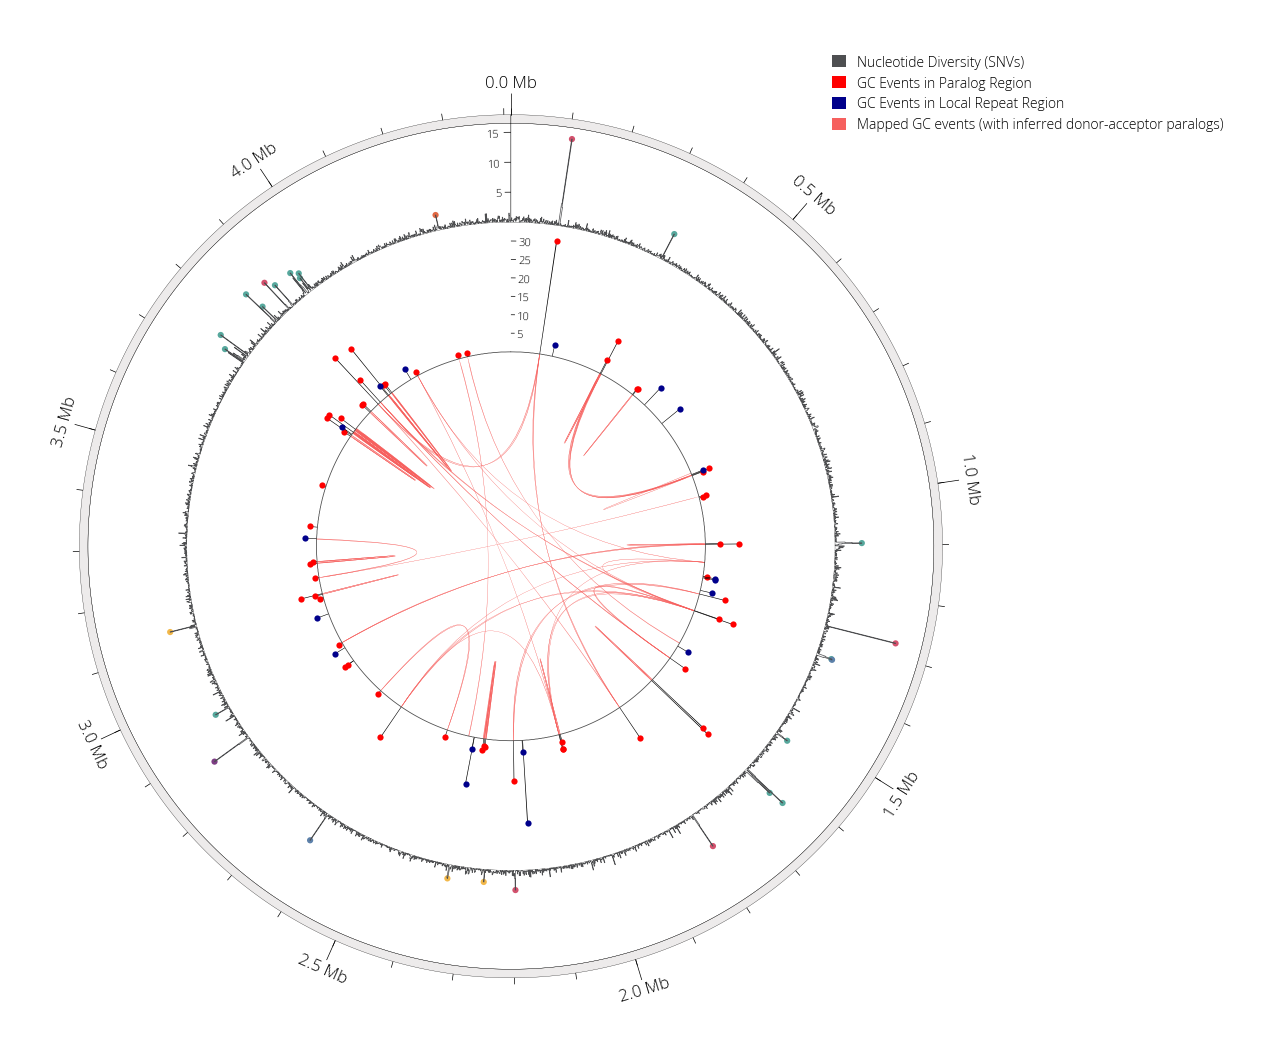

In [158]:
# main fig params
color_dict = {'nucdiv': '#4E4F51',
              'events': '#39618C',
              'GCE_InPR': 'red',
              'GCE_InLocalRepeat': '#00008B',
              'GC_arcs': '#F6605E',
              'hm_arcs' : 'blue', #'grey',
              'scale_track': '#edebeb'}

circos = Circos(sectors={"NC_000962.3": 4411532}, endspace=False)
sector = circos.get_sector("NC_000962.3")




## SCALE TRACK
major_ticks_interval, minor_ticks_interval = 500000, 100000
scale_track = sector.add_track((98, 100))

# background color and line
scale_track.axis(fc=color_dict['scale_track'], 
                 lw=0.2)

# ticks
scale_track.xticks_by_interval(major_ticks_interval, 
                               label_size=12, tick_length=5, 
                               outer=True, show_bottom_line=False,
                               label_orientation='horizontal', line_kws=dict(ec='black'),
                               label_formatter=lambda v: f"{v/ 10 ** 6:.1f} Mb")

scale_track.xticks_by_interval(minor_ticks_interval, tick_length=1.5, show_label=False)



## NUCDIV TRACK

nucdiv_track = sector.add_track((75.1, 98), 
                                r_pad_ratio=0)
nucdiv_track.axis(lw=0.2)

nucdiv_track.line(xx_1kb_All_np[:-19],
                  yy_1kb_All_np[:-19],
                  alpha=1,
                  vmax = 18,
                  lw = 0.5,
                  color = color_dict['nucdiv'],
                  label = "Nucleotide Diveristy (SNPs/kb)")

NDHS_Pos = NucDiv_HSR_PeaksOnly_DF["Middle"].values
NDHS_NucDiv = NucDiv_HSR_PeaksOnly_DF["NucDiv_kb"].values
NDHS_Colors = NucDiv_HSR_PeaksOnly_DF['Func_Category_Peaks'].map(Mtb_GeneCat_ColorDict)

nucdiv_track.scatter(np.array(NDHS_Pos), # + 500,
                     np.array( NDHS_NucDiv),
                     vmax = 18,
                     color = NDHS_Colors,
                     s = 20,
                     marker='o',)

y = [5, 10, 15]
y_labels = ["5", "10", "15",] 
nucdiv_track.yticks(y, y_labels,
              vmax = 16.5, 
              side = "left",
              label_size = 8)

#######################################################


## EVENTS TRACK
events_axis_track = sector.add_track((45, 45.1))
events_axis_track.axis(lw=0.2)

events_track = sector.add_track((45.1, 75), 
                                r_pad_ratio=0)
events_track.axis(lw=0)


### Preprocess GCE Counts Info for plotting ###

# Get positions + numbers for GCE Paralog Region lollipops
x_PR_mid = PR_GCE_Info_WiDetectedGCE_DF["Center"].to_numpy()
y_PR_pGCE = PR_GCE_Info_WiDetectedGCE_DF["N_Events_Putative"].to_numpy()

# Get positions + numbers for GCE NON-PR windows lollipops
x_NonPRWin_mid = Rv_1kb_NucDiv_GCE_NoPR_DF["Middle"].to_numpy()
y_NonPRWin_pGCE = Rv_1kb_NucDiv_GCE_NoPR_DF["N_pGCE"].to_numpy()



############ Plot GCEs detected per PR ############

events_track.bar(np.array(x_PR_mid),
                     np.array( y_PR_pGCE),
                     vmax = np.max(np.array( y_PR_pGCE)) + 4,
                     color= "black", width = 2000)

events_track.scatter(np.array(x_PR_mid),
                     np.array( y_PR_pGCE),
                     vmax = np.max(np.array( y_PR_pGCE)) + 4,
                     
                     color= color_dict['GCE_InPR'],
                     s = 20,
                     marker='o',)

##################################################


############ Plot GCEs detected per NonPR Window ############

events_track.bar(np.array(x_NonPRWin_mid),
                     np.array( y_NonPRWin_pGCE),
                     vmax = np.max(np.array( y_NonPRWin_pGCE)) + 4,
                     color= "black", width = 2000)

events_track.scatter(np.array(x_NonPRWin_mid),
                     np.array( y_NonPRWin_pGCE),
                     vmax = np.max(np.array( y_NonPRWin_pGCE)) + 4,
                     
                     color= color_dict['GCE_InLocalRepeat'],
                     s = 20,
                     marker='o',)

y = [5, 10, 15, 20, 25, 30] 
y_labels = list(map(str, y))
events_track.yticks(y, y_labels,
                    vmax = np.max(np.array( y_PR_pGCE)) + 4)

##############################################################


############ MAPPED EVENTS Links ############

for i, row in HmPair_EventsOnly_DF.iterrows():
    eventRegion = (row["Query_Name"], row["Query_Start"] - 250, row["Query_End"] + 250)
    Possible_DonorRegion = (row["Target_Name"], row["Target_Start"] - 250, row["Target_End"] + 250)

    circos.link(eventRegion,
                Possible_DonorRegion,
                color=color_dict['GC_arcs'],
                direction = 1, alpha = 0.9)

#############################################

fig = circos.plotfig(figsize = (12, 12))

# Add legend
handles = [
    Patch(color=color_dict['nucdiv'], label="Nucleotide Diversity (SNVs)"),
    Patch(color=color_dict['GCE_InPR'], label="GC Events in Paralog Region"),
    Patch(color=color_dict['GCE_InLocalRepeat'], label="GC Events in Local Repeat Region"),
    Patch(color=color_dict['GC_arcs'], label="Mapped GC events (with inferred donor-acceptor paralogs)"),
    #Patch(color= "blue", label="High-Homology Regions w/ no mapped events"),
]

_ = circos.ax.legend(handles=handles, bbox_to_anchor=(1.3, 1), loc="right", fontsize=10)

# Save the figure to a PDF file
fig.savefig('./Fig3.GCE_Results/Fig3.Circos.NucDiv.GCE.MappedGCE_Links.V2.svg')


In [230]:
sum(y_NonPRWin_pGCE)

29

In [229]:
sum(y_PR_pGCE)

296

# Part X

# Extras

# Plot NucDiv + GCE Freq - Linear - Testing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

Div_df = NucDiv_WiGCECt_DF.sort_values(["Start", "End"]).reset_index(drop=True)

# Step arrays (top)
Div_x_step = np.r_[Div_df["Start"].to_numpy(), Div_df["End"].iloc[-1]]
Div_y_step = np.r_[Div_df["NucDiv_kb"].to_numpy(), Div_df["NucDiv_kb"].iloc[-1]]

# Middle positions for lollipops
x_mid = Div_df.query("N_pGCE > 0")["Middle"].to_numpy()
y_pGCE = Div_df.query("N_pGCE > 0")["N_pGCE"].to_numpy()

col = "#4E4F51"

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1,
    figsize=(6.65, 2.8),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 2.2], } # "hspace": 0.08}
)

# --------------------
# Top panel (UNCHANGED)
# --------------------
ax_top.step(Div_x_step, Div_y_step, where="post", color=col, linewidth=0.2)
ax_top.fill_between(Div_x_step, Div_y_step, step="post", color=col, lw=0.3, alpha=0.6)

ax_top.hlines(
    y=ModZ_10_NucDiv, xmin=0, xmax=5000000,
    color="darkgrey", linewidth=0.5, linestyles="--", zorder=3
)

ax_top.set_ylabel("Nucleotide Diversity (SNVs/kb)", fontsize=3)
ax_top.set_ylim(0, 18)

ax_top.set_yticks([0, 3, 6, 9, 12, 15, 18])
ax_top.set_yticklabels([str(t) for t in [0, 3, 6, 9, 12, 15, 18]])

# --------------------
# Bottom panel (lollipop)
# --------------------
ax_bot.vlines(
    x_mid, ymin=0, ymax=y_pGCE,
    color=col, linewidth=0.4, alpha=0.9
)

ax_bot.scatter(
    x_mid, y_pGCE,
    color= 'red', s=3, zorder=3
)

ax_bot.set_ylim(0, 30)
ax_bot.set_ylabel("pGCEs / kb", fontsize=3)
ax_bot.set_xlabel("Genomic Position (Mb)", fontsize=3)

# Shared x-axis formatting
ax_bot.set_xlim(0, 4412000)
ax_bot.xaxis.set_major_formatter(FuncFormatter(bp_to_mb))

sns.despine(ax=ax_top)
sns.despine(ax=ax_bot)
plt.tight_layout()
plt.show()


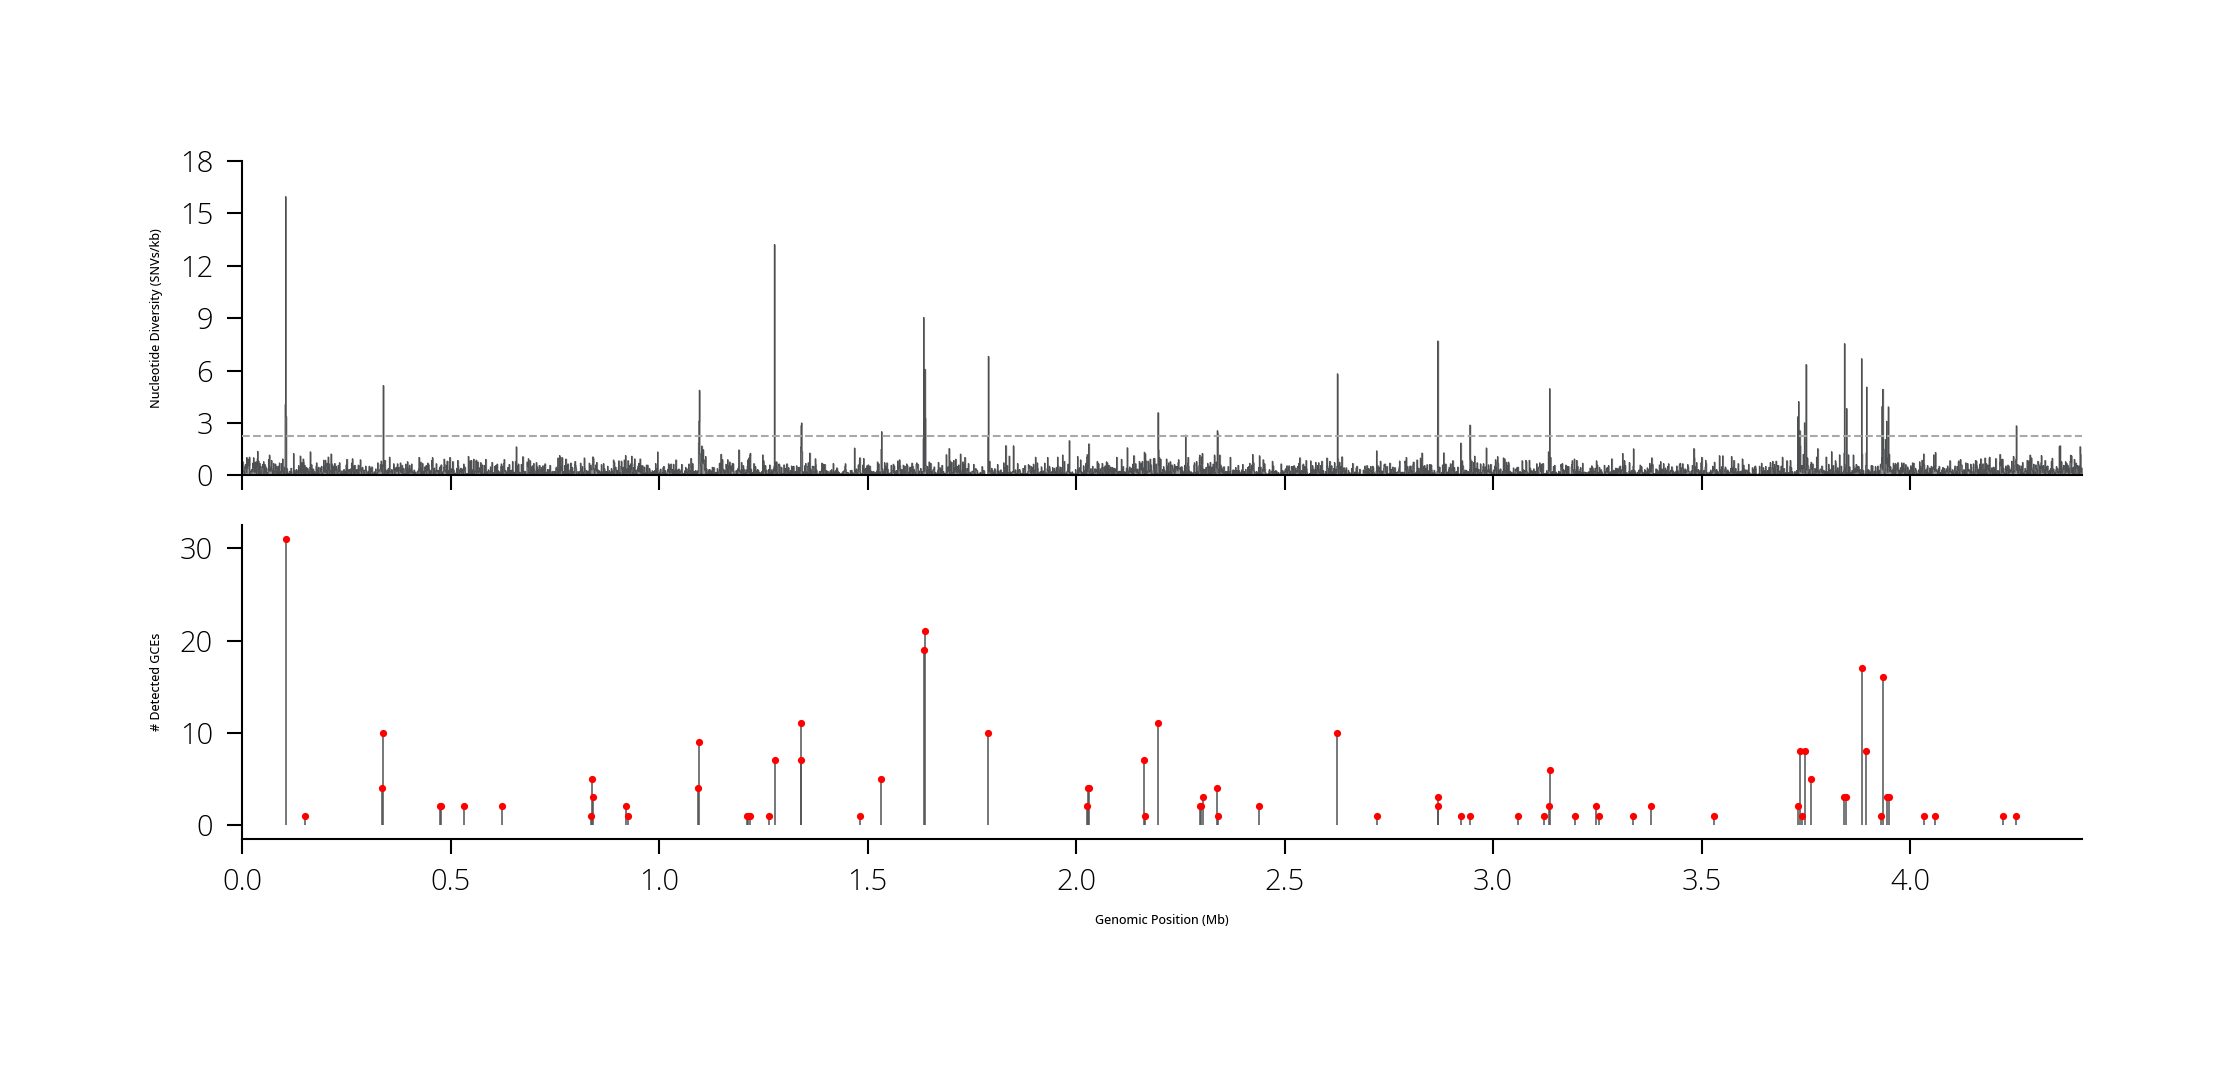

In [214]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

Div_df = NucDiv_WiGCECt_DF.sort_values(["Start", "End"]).reset_index(drop=True)

# Step arrays (top)
Div_x_step = np.r_[Div_df["Start"].to_numpy(), Div_df["End"].iloc[-1]]
Div_y_step = np.r_[Div_df["NucDiv_kb"].to_numpy(), Div_df["NucDiv_kb"].iloc[-1]]

# Middle positions for lollipops
x_mid = Div_df.query("N_pGCE > 0")["Middle"].to_numpy()
y_pGCE = Div_df.query("N_pGCE > 0")["N_pGCE"].to_numpy()

col = "#4E4F51"

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1,
    figsize=(6.65, 2.8),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 2.2], } # "hspace": 0.08}
)

# --------------------
# Top panel (UNCHANGED)
# --------------------
ax_top.step(Div_x_step, Div_y_step, where="post", color=col, linewidth=0.2)
ax_top.fill_between(Div_x_step, Div_y_step, step="post", color=col, lw=0.3, alpha=0.6)

ax_top.hlines(
    y=ModZ_10_NucDiv, xmin=0, xmax=5000000,
    color="darkgrey", linewidth=0.5, linestyles="--", zorder=3
)

ax_top.set_ylabel("Nucleotide Diversity (SNVs/kb)", fontsize=3)
ax_top.set_ylim(0, 18)

ax_top.set_yticks([0, 3, 6, 9, 12, 15, 18])
ax_top.set_yticklabels([str(t) for t in [0, 3, 6, 9, 12, 15, 18]])

# --------------------
# Bottom panel (lollipop)
# --------------------

# Middle positions for GCE Paralog Region lollipops
x_PR_mid = PR_GCE_Info_WiDetectedGCE_DF["Center"].to_numpy()
y_PR_pGCE = PR_GCE_Info_WiDetectedGCE_DF["N_Events_Putative"].to_numpy()


# Middle positions for GCE NON-PR lollipops
x_NonPRWin_mid = Rv_1kb_NucDiv_GCE_NoPR_DF["Middle"].to_numpy()
y_NonPRWin_pGCE = Rv_1kb_NucDiv_GCE_NoPR_DF["N_pGCE"].to_numpy()




##### Plot GCEs detected per PR ######
ax_bot.vlines(x_PR_mid, ymin=0, ymax = y_PR_pGCE,
    color=col, linewidth=0.4, alpha=0.9)

ax_bot.scatter(
    x_PR_mid, y_PR_pGCE,
    color= 'red', s=3, zorder=3)
######################################


##### Plot GCEs detected per NonPR Window ######
ax_bot.vlines(x_NonPRWin_mid, ymin = 0, ymax = y_NonPRWin_pGCE,
    color=col, linewidth = 0.4, alpha=0.9)

ax_bot.scatter(x_NonPRWin_mid, y_NonPRWin_pGCE,
            color= 'red', s = 3, zorder=3)

#############################################


#ax_bot.set_ylim(0, 30)
ax_bot.set_ylabel("# Detected GCEs", fontsize=3)

# Shared x-axis formatting
ax_bot.xaxis.set_major_formatter(FuncFormatter(bp_to_mb))

ax_bot.set_xlabel("Genomic Position (Mb)", fontsize=3)

# Shared x-axis formatting
ax_bot.set_xlim(0, 4412000)
ax_bot.xaxis.set_major_formatter(FuncFormatter(bp_to_mb))

sns.despine(ax=ax_top)
sns.despine(ax=ax_bot)
plt.tight_layout()
plt.show()


# Bonus code for counting pGCE per Local Repeat Region

## 0) Per LocalRepeat Region - Count # of GCEs with NO PR overlap 

In [152]:
RE_CoordCols = ("seqname", "start_0based", "end_1based")
HmRegion_CoordCols = ("Chr", "Start", "End")

GCE_PerLRStats_V2_DF = bf.count_overlaps(GCE_PerLRStats_DF,
                                         GCE_NotInPR_DF,
                                         cols1 = HmRegion_CoordCols,
                                         cols2 = RE_CoordCols).rename(columns={'count': 'N_GCE_NoParalogRegionOvrlap'})

GCE_PerLRStats_V2_DF = bf.count_overlaps(GCE_PerLRStats_V2_DF,
                                         GCE_InPR_DF,
                                         cols1 = HmRegion_CoordCols,
                                         cols2 = RE_CoordCols).rename(columns={'count': 'N_GCE_InParalogRegionOvrlap'})

#### Annotate HHRs by the eventIDs that overlap
# GCE_PerLRStats_V2_DF = annotate_HHR_with_GCE_overlaps(GCE_PerLRStats_V2_DF,
#                                                       GCE_NotInPR_DF)


GCE_PerLRStats_V2_DF.shape

(50, 18)

In [153]:
GCE_PerLRStats_V2_DF.shape

(50, 18)

296

In [154]:
GCE_PerLRStats_V2_DF["pGCE_Count"].sum()

46

In [155]:
GCE_PerLRStats_V2_DF["N_GCE_InParalogRegionOvrlap"].sum()

32

In [159]:
GCE_PerLRStats_V2_DF["N_GCE_NoParalogRegionOvrlap"].sum()

14

In [157]:
14 + 32

46

In [162]:
GCE_PerPRStats_DF["pGCE_Count"].sum()

296

In [163]:
14 + 296

310

In [161]:
#GCE_PerLRStats_NoPROvrlapGCE_V2_DF = 

In [158]:
GCE_PerPRStats_DF.head(4)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,pGCE_Count,CenterOfRegion,Overlap_GC_EventIDs
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,0,80353.5,_
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2,0,81643.5,_
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3,31,104417.5,"Event_001,Event_002,Event_003,Event_004,Event_..."
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4,0,149689.5,_


## 1) Viz GCE freq across Mtb genome - Linear - Vertical Lines Per 1 kb window

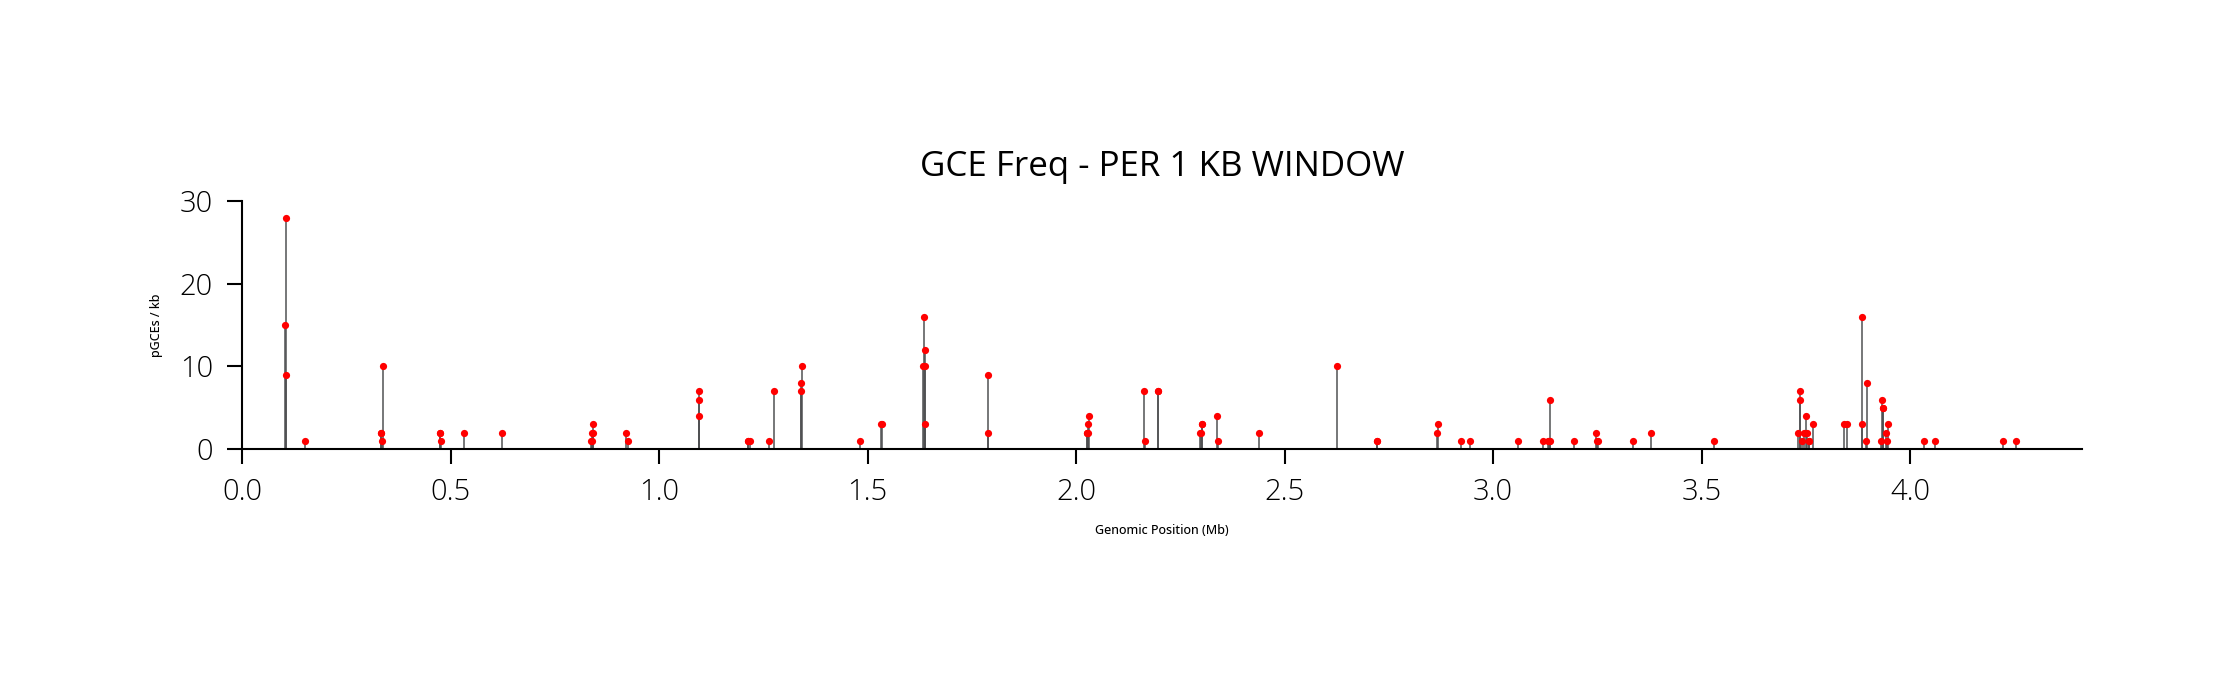

In [217]:
Div_df = NucDiv_WiGCECt_DF.sort_values(["Start", "End"]).reset_index(drop=True)

# Middle positions for lollipops
x_mid = Div_df.query("N_pGCE > 0")["Middle"].to_numpy()
y_pGCE = Div_df.query("N_pGCE > 0")["N_pGCE"].to_numpy()

col = "#4E4F51"

fig, ax1 = plt.subplots(1, 1, figsize=(6.65, 1.5) )

ax1.vlines(
    x_mid, ymin=0, ymax=y_pGCE,
    color=col, linewidth=0.4, alpha=0.9
)

ax1.scatter(
    x_mid, y_pGCE,
    color= 'red', s=3, zorder=3
)

ax1.set_ylim(0, 30)
ax1.set_ylabel("pGCEs / kb", fontsize=3)
ax1.set_xlabel("Genomic Position (Mb)", fontsize=3)

# Shared x-axis formatting
ax1.set_xlim(0, 4412000)
ax1.xaxis.set_major_formatter(FuncFormatter(bp_to_mb))

ax1.set_title("GCE Freq - PER 1 KB WINDOW")

sns.despine(ax=ax1)
plt.tight_layout()
plt.show()
